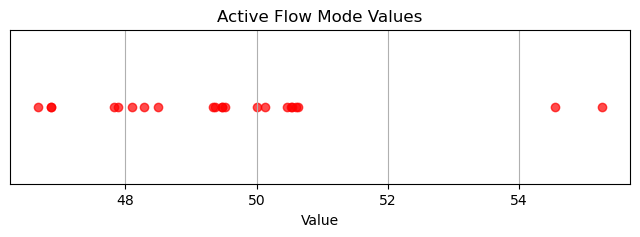

In [31]:
import numpy as np
error = [24.6, 21.3, 16.8, 5.3, 18.8, 21.5, 9.7, 1.3, 19.4, 10.5, 16.0, 11.3, 25.7, 29.5, 27.9, 22.1, 35.1, -0.4, 9.1]
data = [50.54, 48.50, 50.52, 46.67, 49.33, 50.13, 48.28, 46.86, 49.36, 48.10, 50.6, 47.88, 54.55, 49.47, 55.26, 50.63, 50, 50.46, 49.47, 49.52, 47.82, 46.86]
data = np.array(data)
#data = (data * 9/5) + 32
plt.figure(figsize=(8, 2))
y_level = np.zeros_like(data)  # all points at y=0
plt.scatter(data, y_level, color='r', alpha=0.7)
plt.title("Active Flow Mode Values")
plt.xlabel("Value")
plt.yticks([])  # hide y-axis ticks
plt.grid(True, axis='x')
plt.show()

In [ ]:
sites = [4, 5, 9, 10, 11, 12,  18, 29, 30] #good sites    
#sites =  [1, 2, 3, 8, 15, 19, 21, 22, 25, 27, 28] #bad sites
import sys
import pandas as pd

setpoint = 48.9

consume_total = []
deliver_total = []

field_consumed = []
field_delivered = []

for site_number in sites:
    file_path = Path(f"output_site_120V_{site_number}_(L)_{setpoint}.csv")

    if not file_path.is_file():  # .is_file() is safer than .exists() as it confirms it's not a folder
        print(f"File not found: {file_path}")
        continue

    data = pd.read_csv(file_path) #output data
    data_ground = pd.read_csv(f'..\\..\\ochre\\defaults\\Input Files\\Temperature Values\\120V_temperatures_{site_number}.csv') #ground truth\
    data_raw = pd.read_csv(f'..\\120V_site_raw\site_{site_number}.csv')      
    flow_raw = pd.read_csv(f'..\\..\\ochre\\defaults\\Input Files\\120V_Flow\\net_flow_{site_number}_120V.csv')

    delivered_field = pd.read_csv(f'120V_hot_water_{site_number}.csv')    


    print("Site {site_number} has {n} days of data".format(site_number=site_number, n=len(flow_raw)/1440))

    #daily gallon comparison
    MINUTES_PER_DAY = 1440
    FIFTEEN_MINUTES_PER_DAY = 96

    import numpy as np
    #timezone casting
    ground_electric = pd.DataFrame()
    ground_electric['Time'] = data_raw['local_datetime']
    ground_electric['Time'] = pd.to_datetime(ground_electric['Time'], utc=True)
    ground_electric['HPWH_kw'] = data_raw['HPWH_pwr_kW'] #gets 15 minute time power readings
    data_ground['Time'] = pd.to_datetime(data_ground['Time'], utc=True)

    #derive ground kWh from raw site data

    #perform an inner join to get 15 minute intervals in our flow data
    ground = pd.merge(data_ground, ground_electric, on='Time', how='inner')

    #cast na values to 0
    ground_kw  = pd.to_numeric(ground['HPWH_kw'], errors='coerce').fillna(0).astype(float)
    ground_kw = ground_kw.values

    #Trim outputted data
    daily_flow      = pd.to_numeric(data['Draw Data'], errors='coerce').values
    daily_delivered = pd.to_numeric(data['Hot Water Delivered (kW)'], errors='coerce').values
    electric  = pd.to_numeric(data['Water Heating Electric Power (kW)'], errors='coerce').values
    ground_delivered = pd.to_numeric(delivered_field['Hot Water Delivered (W)'], errors = 'coerce').values

    # Trim to a multiple of 1440 (drops incomplete trailing day)
    n_days = len(daily_flow) // MINUTES_PER_DAY
    n_days = n_days - 15#

    daily_flow      = daily_flow[:n_days * MINUTES_PER_DAY].reshape(n_days, MINUTES_PER_DAY).sum(axis=1)
    daily_delivered = daily_delivered[:n_days * MINUTES_PER_DAY].reshape(n_days, MINUTES_PER_DAY).sum(axis=1) /60 #kWh
    daily_electric  = electric[:n_days * MINUTES_PER_DAY].reshape(n_days, MINUTES_PER_DAY).sum(axis=1) /60 #kWh
    ground_kwh = ground_kw[0:n_days * FIFTEEN_MINUTES_PER_DAY].reshape(n_days, FIFTEEN_MINUTES_PER_DAY).sum(axis=1) / 4  #kWh
    daily_ground_delivered = ground_delivered[:n_days * MINUTES_PER_DAY].reshape(n_days, MINUTES_PER_DAY).sum(axis=1) /1000/ 60 #kWh

    n_days

    e = daily_electric[7:-7]
    g = ground_kwh[7:-7]
    d = daily_delivered[7:-7]
    d2 = daily_ground_delivered[7:-7]

    if site_number in [1, 2, 3, 5, 8, 15, 19, 21, 22, 25, 27, 28]:
        e = daily_electric[60:-7]
        g = ground_kwh[60:-7]
        d = daily_delivered[60:-7]
        d2 = daily_ground_delivered[60:-7]

    consume_total.append(e.sum())
    field_consumed.append(g.sum())
    deliver_total.append(d.sum())
    field_delivered.append(d2.sum())


C:\Users\m10950449\AppData\Local\Temp\ipykernel_39616\3470867321.py:23: DtypeWarning: Columns (46,50,55) have mixed types. Specify dtype option on import or set low_memory=False.
  data_raw = pd.read_csv(f'..\\120V_site_raw\site_{site_number}.csv')


Site 2 has 372.34444444444443 days of data


C:\Users\m10950449\AppData\Local\Temp\ipykernel_39616\3470867321.py:23: DtypeWarning: Columns (46,50,55) have mixed types. Specify dtype option on import or set low_memory=False.
  data_raw = pd.read_csv(f'..\\120V_site_raw\site_{site_number}.csv')


Site 4 has 368.51458333333335 days of data


C:\Users\m10950449\AppData\Local\Temp\ipykernel_39616\3470867321.py:23: DtypeWarning: Columns (46,50,55) have mixed types. Specify dtype option on import or set low_memory=False.
  data_raw = pd.read_csv(f'..\\120V_site_raw\site_{site_number}.csv')


...

Site 12 has 360.9534722222222 days of data


C:\Users\m10950449\AppData\Local\Temp\ipykernel_39616\3470867321.py:23: DtypeWarning: Columns (46,50,55) have mixed types. Specify dtype option on import or set low_memory=False.
  data_raw = pd.read_csv(f'..\\120V_site_raw\site_{site_number}.csv')


Site 18 has 320.6638888888889 days of data
Site 29 has 276.37569444444443 days of data


C:\Users\m10950449\AppData\Local\Temp\ipykernel_39616\3470867321.py:23: DtypeWarning: Columns (46,50,55) have mixed types. Specify dtype option on import or set low_memory=False.
  data_raw = pd.read_csv(f'..\\120V_site_raw\site_{site_number}.csv')


Site 30 has 248.72152777777777 days of data


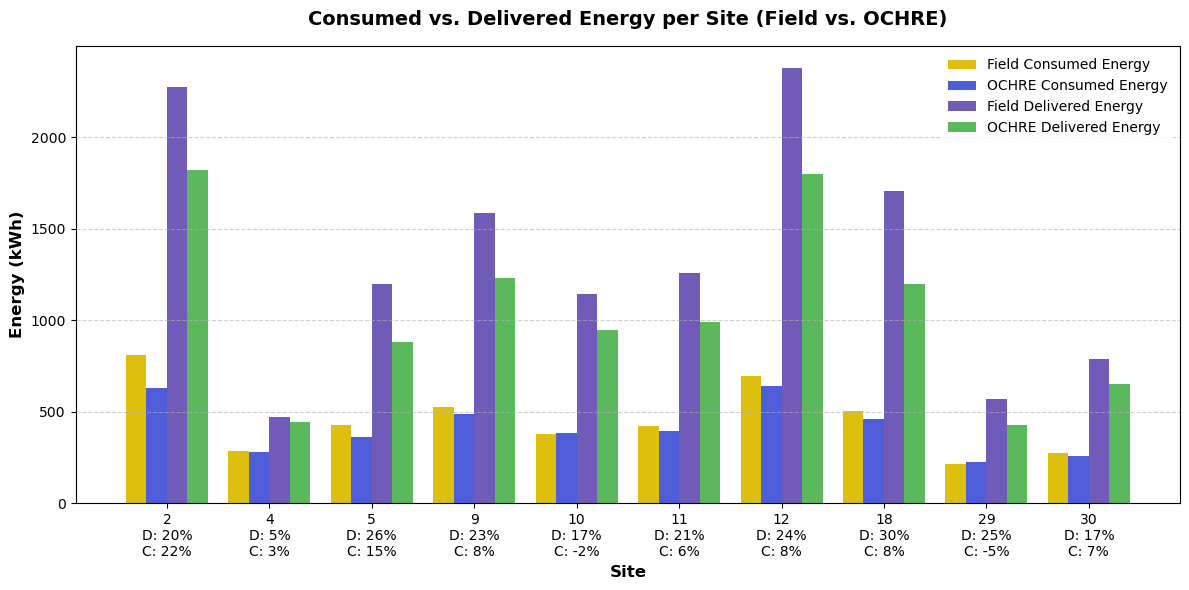

In [44]:

# --- 1. Site/Period Labels ---
num_sites = len(consume_total)

# Formatted labels with percentages
site_labels = [
    f"{sites[i]}\n"
    f"D: {((field_delivered[i] - deliver_total[i]) / field_delivered[i]) * 100:.0f}%\n"
    f"C: {((field_consumed[i] - consume_total[i]) / field_consumed[i]) * 100:.0f}%"
    for i in range(len(sites))
]

# --- 2. Plot Setup ---
x = np.arange(num_sites)
width = 0.2  # Reduced width to fit 4 side-by-side bars cleanly

fig, ax = plt.subplots(figsize=(12, 6))

# Assign distinct offsets to all 4 bars
rects1 = ax.bar(x - 1.5 * width, field_consumed, width, label='Field Consumed Energy', color='#dfbf0d')
rects2 = ax.bar(x - 0.5 * width, consume_total, width, label='OCHRE Consumed Energy', color="#4f5dd9")
rects3 = ax.bar(x + 0.5 * width, field_delivered, width, label='Field Delivered Energy', color='#705cb8')
rects4 = ax.bar(x + 1.5 * width, deliver_total, width, label='OCHRE Delivered Energy', color='#5cb85c')

# --- 3. Labels and Styling ---
ax.set_xlabel('Site', fontsize=12, fontweight='bold')
ax.set_ylabel('Energy (kWh)', fontsize=12, fontweight='bold')
ax.set_title('Consumed vs. Delivered Energy per Site (Field vs. OCHRE)', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(site_labels)
ax.legend(frameon=True, facecolor='white', edgecolor='none')
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

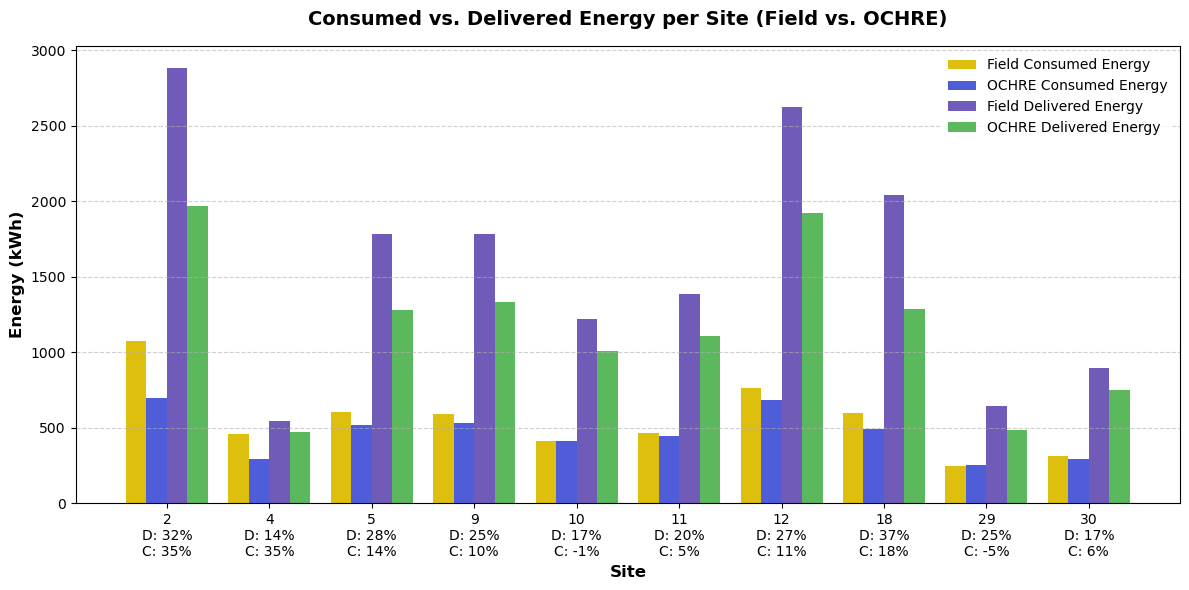

In [26]:
#Compare hot water consumed and delivered
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

sites =  [1, 3, 8, 15, 19, 21, 22, 25, 27, 28] #bad sites
sites = [2, 4, 5, 9, 10, 11, 12,  18, 29, 30] #good sites
consume_total = []
deliver_total = []

field_consumed = []
field_delivered = []
for site in sites:
    data = pd.read_csv(f'120V_hot_water_{site}.csv')
    power_data = pd.read_csv(f'..\\..\\ochre\\defaults\\Input Files\\Temperature Values\\120V_temperatures_{site}.csv')
    consumed = power_data['HPWH_pwr_kW']/60
    delivered = data['Hot Water Delivered (W)']/1000/60

    field_consumed.append(consumed.sum())
    field_delivered.append(delivered.sum())

    #OCHRE
    data = pd.read_csv(f'output_site_120V_{site}_(L)_48.9.csv')
    consumed = data['Water Heating Electric Power (kW)']/60
    delivered = data['Hot Water Delivered (kW)']/60

    consume_total.append(consumed.sum())
    deliver_total.append(delivered.sum())

# Site/Period labels dynamically generated based on array length
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Site/Period Labels ---
num_sites = len(consume_total)

# Formatted labels with percentages
site_labels = [
    f"{sites[i]}\n"
    f"D: {((field_delivered[i] - deliver_total[i]) / field_delivered[i]) * 100:.0f}%\n"
    f"C: {((field_consumed[i] - consume_total[i]) / field_consumed[i]) * 100:.0f}%"
    for i in range(len(sites))
]

# --- 2. Plot Setup ---
x = np.arange(num_sites)
width = 0.2  # Reduced width to fit 4 side-by-side bars cleanly

fig, ax = plt.subplots(figsize=(12, 6))

# Assign distinct offsets to all 4 bars
rects1 = ax.bar(x - 1.5 * width, field_consumed, width, label='Field Consumed Energy', color='#dfbf0d')
rects2 = ax.bar(x - 0.5 * width, consume_total, width, label='OCHRE Consumed Energy', color="#4f5dd9")
rects3 = ax.bar(x + 0.5 * width, field_delivered, width, label='Field Delivered Energy', color='#705cb8')
rects4 = ax.bar(x + 1.5 * width, deliver_total, width, label='OCHRE Delivered Energy', color='#5cb85c')

# --- 3. Labels and Styling ---
ax.set_xlabel('Site', fontsize=12, fontweight='bold')
ax.set_ylabel('Energy (kWh)', fontsize=12, fontweight='bold')
ax.set_title('Consumed vs. Delivered Energy per Site (Field vs. OCHRE)', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(site_labels)
ax.legend(frameon=True, facecolor='white', edgecolor='none')
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()
    



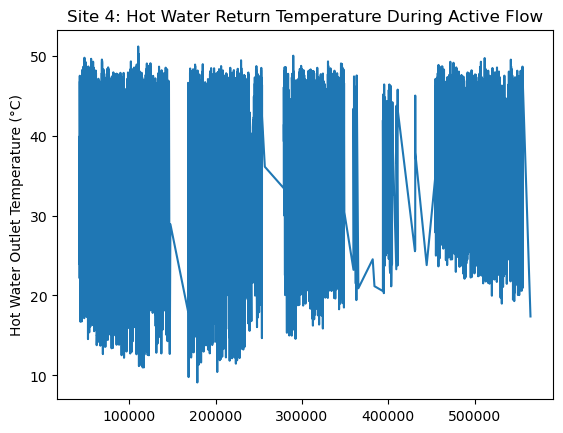

0    46.391667
1    46.494444
2    46.668056
Name: tempHot, dtype: float64
Site 4
Max Temp
51.14907407407407
tempHot
45–46 °C    28.0
46–47 °C    32.6
47–48 °C    28.2
48–49 °C     9.6
49–50 °C     1.4
50–51 °C     0.1
Name: proportion, dtype: float64


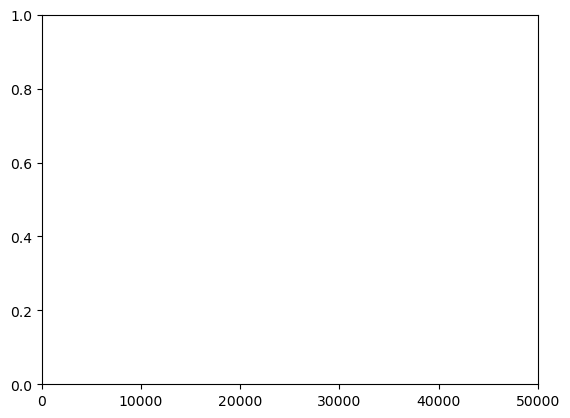

In [7]:
#Evaluate hot water outlet temperatures
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

sites = [1, 2, 3, 4, 5, 8, 9, 10, 11, 12,  15, 18, 19, 21, 22, 23, 24, 25, 27, 28, 29, 30]
#sites =  [1, 3, 8, 15, 19, 21, 22, 25, 27, 28]
sites = [4]
site_mean = {}
site_mode = {}
for site_number in sites:
    setpoint = 48.9


    data_temp = pd.read_csv(f'120V_hot_water_{site_number}.csv') #pd.read_csv(f'..\\..\\ochre\\defaults\\Input Files\\Temperature Values\\120V_temperatures_{site_number}.csv')      


    # Filter rows where flow is greater than 0, then select the temperature column
    filtered_temp = data_temp.loc[data_temp['flow_L_per_min'] > 0, 'tempHot']

    # Plot the filtered data
    plt.plot(filtered_temp)
    plt.ylabel('Hot Water Outlet Temperature (°C)')
    plt.title(f'Site {site_number}: Hot Water Return Temperature During Active Flow')
    plt.show()
    plt.xlim(0, 50000)
    print(filtered_temp.mode())

    print(f"Site {site_number}")
    print("Max Temp")
    print(filtered_temp.max())
    import pandas as pd
    import numpy as np

    # 1. Define 1°C bins based on the min and max temp in filtered_temp
    min_temp = 45
    max_temp = int(np.ceil(filtered_temp.max()))

    bins = range(min_temp, max_temp + 1)
    labels = [f"{b}–{b+1} °C" for b in bins[:-1]]

    # 2. Categorize temperatures and compute percentages
    pct_dist = (
        pd.cut(filtered_temp, bins=bins, labels=labels, right=False)
        .value_counts(normalize=True, sort=False) * 100
    ).round(1)

    # 3. Print only bins that have data (> 0%)
    print(pct_dist[pct_dist > 0])


{1: 0    50.539352
Name: tempHot, dtype: float64, 2: 0    48.50463
Name: tempHot, dtype: float64, 3: 0    50.516667
Name: tempHot, dtype: float64, 4: 0    46.391667
1    46.494444
2    46.668056
Name: tempHot, dtype: float64, 5: 0    49.327315
Name: tempHot, dtype: float64, 8: 0    49.761574
1    49.768981
2    49.799074
3    50.084722
4    50.108796
5    50.128704
Name: tempHot, dtype: float64, 9: 0    48.276852
Name: tempHot, dtype: float64, 10: 0     46.529167
1     46.605556
2     46.685648
3     46.714815
4     46.739352
5     46.756944
6     46.784722
7     46.791204
8     46.832870
9     46.850926
10    46.856481
Name: tempHot, dtype: float64, 11: 0    49.363889
Name: tempHot, dtype: float64, 12: 0    48.101852
Name: tempHot, dtype: float64, 15: 0    49.562963
1    50.435185
2    50.448148
3    50.567593
4    50.609259
Name: tempHot, dtype: float64, 18: 0    47.883796
Name: tempHot, dtype: float64, 19: 0    53.255556
1    54.795833
2    54.825926
3    55.834722
Name: tempHot, dt

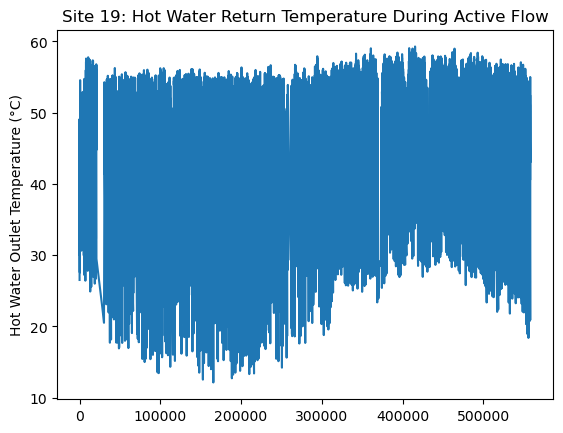

In [59]:
#Evaluate hot water outlet temperatures
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

sites = [1, 2, 3, 4, 5, 8, 9, 10, 11, 12,  15, 18, 19, 21, 22, 23, 24, 25, 27, 28, 29, 30]
#sites =  [1, 2, 3, 5, 8, 15, 19, 21, 22, 25, 27, 28]
sites = [19]
for site_number in sites:
    setpoint = 48.9


    data_temp = pd.read_csv(f'120V_hot_water_{site_number}.csv') #pd.read_csv(f'..\\..\\ochre\\defaults\\Input Files\\Temperature Values\\120V_temperatures_{site_number}.csv')      


    # Filter rows where flow is greater than 0, then select the temperature column
    filtered_temp = data_temp.loc[data_temp['flow_L_per_min'] > 0, 'tempHot']

    # Plot the filtered data
    plt.plot(filtered_temp)
    plt.ylabel('Hot Water Outlet Temperature (°C)')
    plt.title(f'Site {site_number}: Hot Water Return Temperature During Active Flow')
    plt.show()


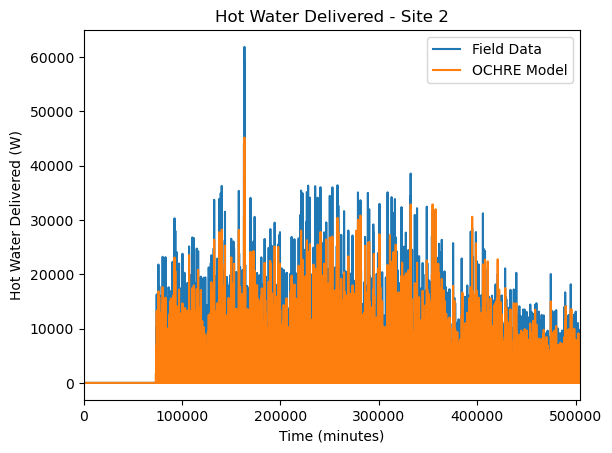

Site 2 - Error: 0.19885145024308565


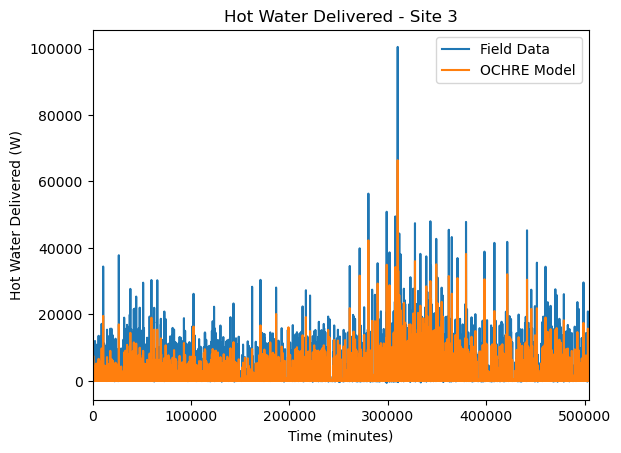

Site 3 - Error: 0.36221083736410936


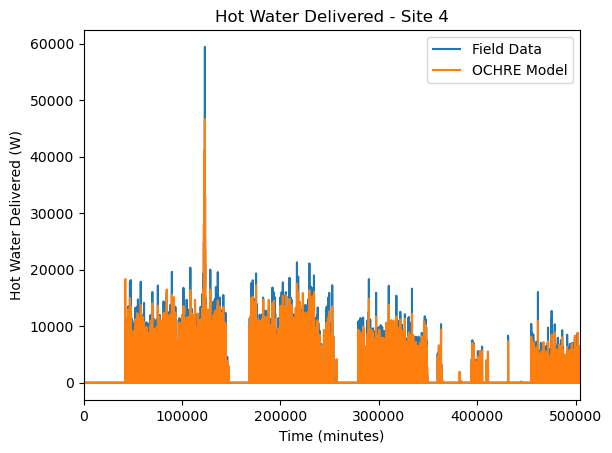

Site 4 - Error: 0.08162583086954518


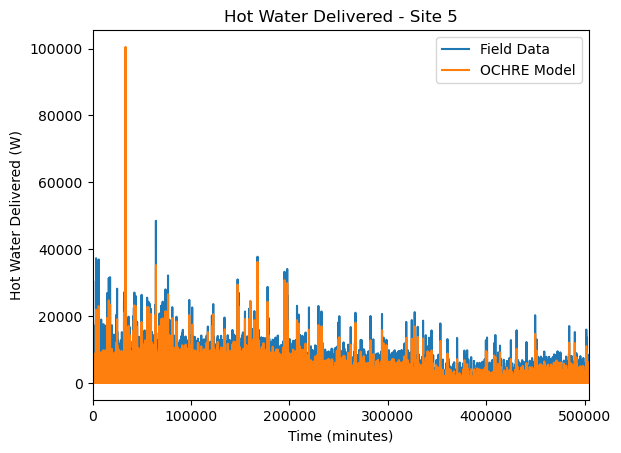

Site 5 - Error: 0.23943412896746083


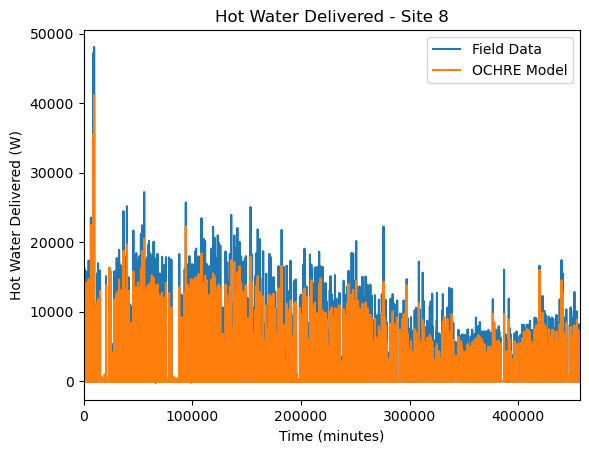

Site 8 - Error: 0.20111271493328933


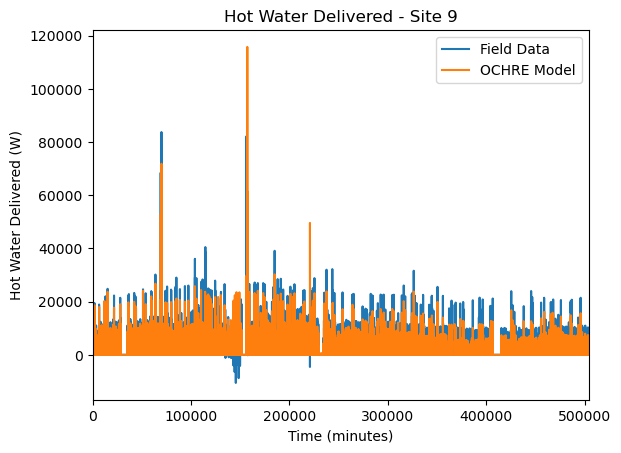

Site 9 - Error: 0.21914104533088322


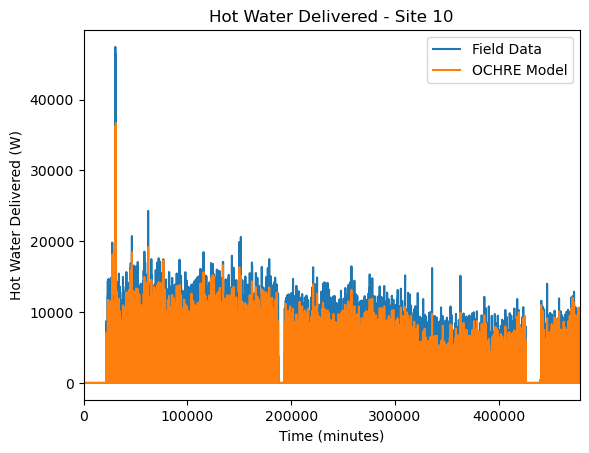

Site 10 - Error: 0.16828533043822957


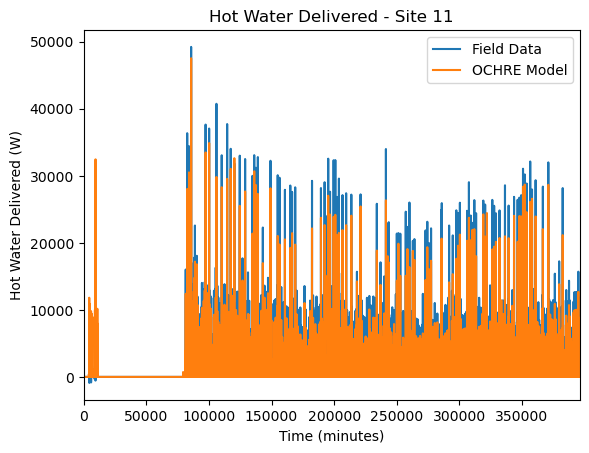

Site 11 - Error: 0.19642104757143428


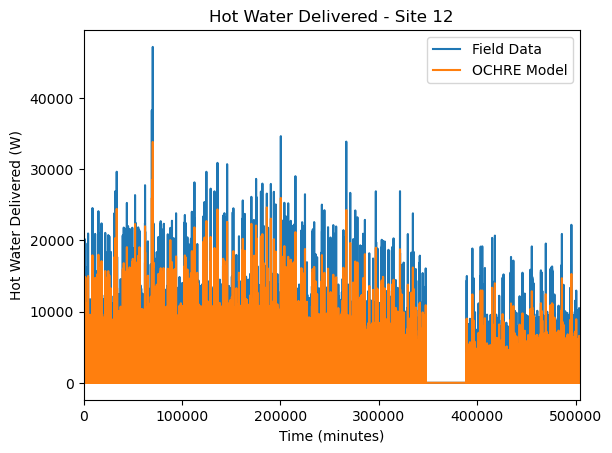

Site 12 - Error: 0.2463251926858611
HWD Errors for all sites:
Site 2 - Error: 0.19885145024308565
Site 3 - Error: 0.36221083736410936
Site 4 - Error: 0.08162583086954518
Site 5 - Error: 0.23943412896746083
Site 8 - Error: 0.20111271493328933
Site 9 - Error: 0.21914104533088322
Site 10 - Error: 0.16828533043822957
Site 11 - Error: 0.19642104757143428
Site 12 - Error: 0.2463251926858611


In [18]:
#Compare Hot Water Delivered for Rheem 120V sites

from pathlib import Path

import pandas as pd
import numpy as np
import pandas as pd

errors = {}
#Get Rheem ground truth data and field data
for site_number in [2, 3, 4, 5, 8, 9, 10, 11, 12]:
    setpoint = 48.9
    file_path = Path(f"output_site_120V_{site_number}_(L)_{setpoint}.csv")

    data = pd.read_csv(file_path) #output data
    field_hwd = pd.read_csv(f'120V_hot_water_{site_number}.csv') #field data

    import matplotlib.pyplot as plt

    plt.plot(field_hwd["Hot Water Delivered (W)"], label="Field Data")
    plt.plot(data["Hot Water Delivered (W)"], label="OCHRE Model")
    plt.legend()
    plt.xlabel("Time (minutes)")
    plt.ylabel("Hot Water Delivered (W)")
    plt.title(f"Hot Water Delivered - Site {site_number}")
    plt.xlim(0, len(data))
    plt.show()
    error = (field_hwd["Hot Water Delivered (W)"][0:len(data)].sum() - data["Hot Water Delivered (W)"].sum())/field_hwd["Hot Water Delivered (W)"][0:len(data)].sum()
    print(f"Site {site_number} - Error: {error}")
    errors[site_number] = error

print("HWD Errors for all sites:")
for site, error in errors.items():
    print(f"Site {site} - Error: {error}")


In [69]:
compute_error(1, 50.53)

C:\Users\m10950449\AppData\Local\Temp\ipykernel_7080\1998413583.py:17: DtypeWarning: Columns (46,50,55) have mixed types. Specify dtype option on import or set low_memory=False.
  data_raw = pd.read_csv(f'..\\120V_site_raw\site_{site_number}.csv')


Site 1 has 360.9222222222222 days of data
Site 1
                    Simulated  Ground truth  Difference (GT − Sim)
Metric                                                            
Total energy (kWh)    154.602       289.510                134.908
Mean (kWh/day)          0.588         1.101                  0.513
Std dev                 0.214         0.634                  0.420
Min                     0.365         0.322                 -0.042
Median (p50)            0.480         0.889                  0.409
p75                     0.785         1.390                  0.605
p90                     0.914         2.011                  1.097
Max                     1.101         3.696                  2.595
— MAE                   0.539           NaN                    NaN
— RMSE                  0.759           NaN                    NaN
— MAPE (%)             39.764           NaN                    NaN
— R²                   -0.434           NaN                    NaN
Percent Error

46.59883280196348

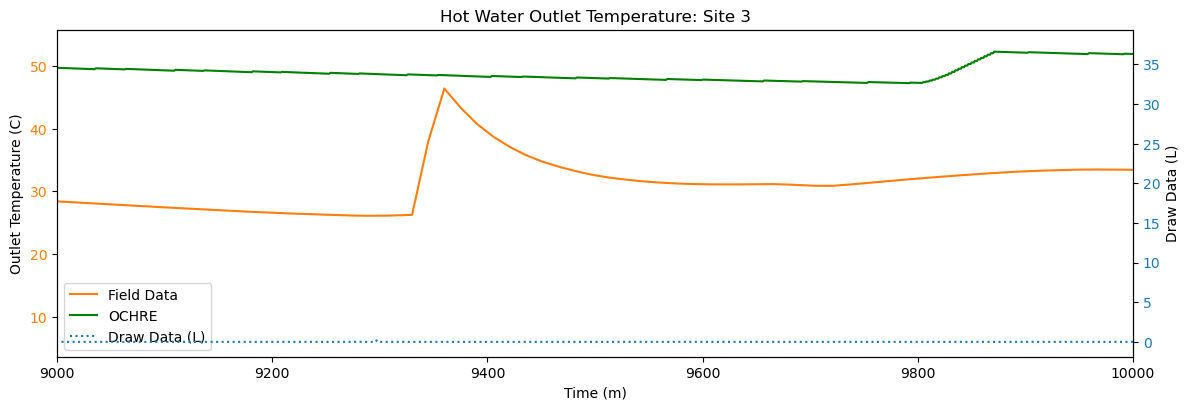

In [7]:
#Compare Hot Water Outlet Temperature between sites
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#for site in [1, 2, 3, 5, 8, 15, 19, 21, 22, 25, 27, 28]:
site_setpoints = {
    1: 50.53, 2:48.9, 3:52.27, 4:49.52, 5:60, 7:49.35, 8:50.54, 9:48.34, 10:49.07, 11:50, 12:49.06, 13:49.28, 14:50.96, 15:51.43, 16:53.15, 18:48.53, 19:58.11, 21:50.16, 22:56.71, 23:51.12, 24:50.75, 25:51.22, 27:51.05, 28:51.6, 29:49.75, 30:50.75
}
for site in [3]:

    field = pd.read_csv(f'..\\..\\ochre\\defaults\\Input Files\\Temperature Values\\120V_temperatures_{site}.csv')
    lab = pd.read_csv(f'output_site_120V_{site}_(L)_{site_setpoints[site]}.csv')


    fig, ax1 = plt.subplots(figsize=(12, 4))
    ax1.plot(field['return_hot_water_temp_C'], label='Field Data', color='tab:orange')
    ax1.plot(lab['Hot Water Outlet Temperature (C)'], label='OCHRE', color='green')
    ax1.set_ylabel('Outlet Temperature (C)')
    # ax1.plot(bisection['Water Heating Electric Power (kWh)'], label='KWh', color='tab:orange')
    # ax1.set_ylabel('Water Heating Electric Power (kWh)')
    ax1.set_xlabel('Time (m)')
    ax1.tick_params(axis='y', labelcolor='tab:orange')

    ax2 = ax1.twinx()
    ax2.plot(field['flow_L_per_min'], label='Draw Data (L)', linestyle='dotted', color='tab:blue')
    ax2.set_ylabel('Draw Data (L)')
    ax2.tick_params(axis='y', labelcolor='tab:blue')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')
    plt.xlim(9000, 10000)
    plt.tight_layout()
    plt.title(f"Hot Water Outlet Temperature: Site {site}")
    plt.show()



In [13]:
field_hwd

,Time,inlet_cold_water_temp_C,inlet_air_temp_C,inlet_RH,outlet_hot_water_Gal,return_hot_water_temp_C,wet_bulb_C,flow_L_per_min,tempHot,tempCold,Field Hot Water Delivered (W),Field HWD,Unnamed: 12,Unnamed: 13,2190151521,Unnamed: 15,OCHRE Hot Water Delivered (W)
0,11/3/2022 4:00,14.121049,13.960000,59.200000,0.0,18.187562,9.818320,0.0,13.387037,12.308796,0.0,0.0,NaN,NaN,NaN,NaN,0.0
1,11/3/2022 4:01,14.121646,13.960667,59.240000,0.0,18.159599,9.823255,0.0,13.376852,12.298148,0.0,0.0,NaN,NaN,NaN,NaN,0.0
2,11/3/2022 4:02,14.122243,13.961333,59.280000,0.0,18.131636,9.828191,0.0,13.365278,12.294907,0.0,0.0,NaN,NaN,NaN,NaN,0.0
3,11/3/2022 4:03,14.122840,13.962000,59.320000,0.0,18.103673,9.833126,0.0,13.361574,12.290741,0.0,0.0,NaN,NaN,NaN,NaN,0.0
4,11/3/2022 4:04,14.123436,13.962667,59.360000,0.0,18.075710,9.838060,0.0,13.330093,12.261574,0.0,0.0,NaN,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
521036,10/30/2023 23:56,21.301356,23.186000,35.033333,0.0,23.217442,13.966213,0.0,11.932870,9.456019,0.0,0.0,NaN,NaN,NaN,NaN,NaN
521037,10/30/2023 23:57,21.308247,23.162000,35.000000,0.0,23.219463,13.942760,0.0,11.917130,9.456944,0.0,0.0,NaN,NaN,NaN,NaN,NaN
521038,10/30/2023 23:58,21.315138,23.138000,34.966667,0.0,23.221484,13.919316,0.0,11.962037,9.528241,0.0,0.0,NaN,NaN,NaN,NaN,NaN
521039,10/30/2023 23:59,21.322029,23.114000,34.933333,0.0,23.223504,13.895878,0.0,11.912963,9.518056,0.0,0.0,NaN,NaN,NaN,NaN,NaN


In [4]:
field_hwd

,Time,inlet_cold_water_temp_C,inlet_air_temp_C,inlet_RH,outlet_hot_water_Gal,return_hot_water_temp_C,HPWH_pwr_kW,wet_bulb_C,flow_L_per_min,tempHot,tempCold,Hot Water Delivered (W)
0,2022-08-31 04:00:00,25.657296,31.320000,45.300000,0.000000,26.165428,0.003,22.29,0.0,25.926360,25.456444,0.0
1,2022-08-31 04:01:00,25.655254,31.312667,45.300000,0.000000,26.162711,0.003,22.29,0.0,25.926310,25.456298,0.0
2,2022-08-31 04:02:00,25.653213,31.305333,45.300000,0.000000,26.159993,0.003,22.28,0.0,25.926261,25.456153,0.0
3,2022-08-31 04:03:00,25.651171,31.298000,45.300000,0.000000,26.157276,0.003,22.28,0.0,25.926211,25.456007,0.0
4,2022-08-31 04:04:00,25.649130,31.290667,45.300000,0.000000,26.154558,0.003,22.27,0.0,25.926161,25.455862,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
613196,2023-10-30 23:56:00,16.218175,20.588667,59.233333,0.004151,40.393392,0.002,15.61,0.0,11.905093,4.581944,0.0
613197,2023-10-30 23:57:00,16.049025,20.594000,59.300000,0.004225,41.815230,0.002,15.63,0.0,11.867130,4.608333,0.0
613198,2023-10-30 23:58:00,15.879874,20.599333,59.366667,0.004300,43.237068,0.002,15.64,0.0,11.749074,4.551852,0.0
613199,2023-10-30 23:59:00,15.710724,20.604667,59.433333,0.004374,44.658905,0.002,15.65,0.0,11.714815,4.592130,0.0


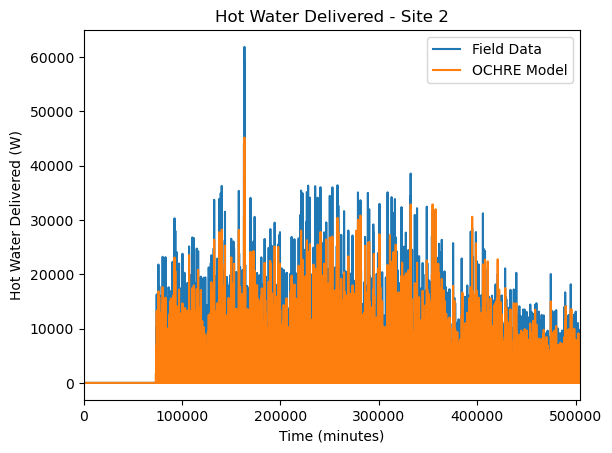

In [ ]:
import matplotlib.pyplot as plt

plt.plot(field_hwd["Hot Water Delivered (W)"], label="Field Data")
plt.plot(data["Hot Water Delivered (W)"], label="OCHRE Model")
plt.legend()
plt.xlabel("Time (minutes)")site_setpoints = {
    1: 50.53, 2:48.82, 3:52.27, 4:49.52, 5:60, 7:49.35, 8:50.54, 9:48.34, 10:49.07, 11:50, 12:49.06, 13:49.28, 14:50.96, 15:51.43, 16:53.15, 18:48.53, 19:58.11, 21:50.16, 22:56.71, 23:51.12, 24:50.75, 25:51.22, 27:51.05, 28:51.6, 29:49.75, 30:50.75
}
plt.ylabel("Hot Water Delivered (W)")
plt.title(f"Hot Water Delivered - Site {site_number}")
plt.xlim(0, len(data))
plt.show()


In [23]:

from pathlib import Path

import pandas as pd
import numpy as np
import pandas as pd

#compute error for individual sites (site number, setpoint)
site_number = 2
setpoint = 48.9
file_path = Path(f"120V_site_output\\output_site_120V_{site_number}_(L)_{setpoint}.csv")

data = pd.read_csv(file_path) #output data
data_temp = pd.read_csv(f'..\\ochre\\defaults\\Input Files\\Temperature Values\\120V_temperatures_{site_number}.csv')      
data_flow = pd.read_csv(f'120V_site_raw\\site_{site_number}_flow.csv')

data_temp.loc[data_flow['L_per_min'].isna(), 'HPWH_pwr_kW'] = 0 #set nan flow values to 0 in power column
#daily gallon comparison
MINUTES_PER_DAY = 1440

# 2. Map power to data_temp from the ground truth file
# (Replace 'kW' with the actual power column name in your data_ground file)
data_ground = data_temp['HPWH_pwr_kW']






FileNotFoundError: [Errno 2] No such file or directory: '120V_site_output\\output_site_120V_2_(L)_48.9.csv'

In [ ]:


import pandas as pd
for site_number in range(1, 31):
    try:
        data_temp = pd.read_csv(f'..\\..\\ochre\\defaults\\Input Files\\Temperature Values\\120V_temperatures_{site_number}.csv')     
        if site_number == 7:
            print(f"Site {site_number}: {data_temp['return_hot_water_temp_C'].nlargest(2).iloc[-1]}") #return second max
        else:
            print(f"Site {site_number}: {data_temp['return_hot_water_temp_C'].max()}") 
    except:
        continue



Site 1: 50.53805555555556
Site 2: 48.81923809523809
Site 3: 52.2692901234568
Site 4: 49.51555555555555
Site 5: 59.222787193973645
Site 7: 124.85276353276352
Site 8: 50.53787037037037
Site 9: 124.48961988304092
Site 10: 49.07440699126092
Site 11: 49.99785847299813
Site 12: 49.05633147113595
Site 13: 49.28117283950617
Site 14: 50.95941358024691
Site 15: 51.43135802469135
Site 16: 53.15364197530865
Site 18: 48.52972222222222
Site 19: 58.11067415730336
Site 21: 50.15732464307884
Site 22: 56.71216049382716
Site 23: 51.11905648665426
Site 24: 50.75186219739293
Site 25: 51.22134831460673
Site 27: 51.05104938271606
Site 28: 51.59154320987653
Site 29: 49.75012484394507
Site 30: 50.751489757914335


In [9]:
compute_error(1, 50.53)

C:\Users\m10950449\AppData\Local\Temp\ipykernel_34764\1998413583.py:17: DtypeWarning: Columns (46,50,55) have mixed types. Specify dtype option on import or set low_memory=False.
  data_raw = pd.read_csv(f'..\\120V_site_raw\site_{site_number}.csv')


Site 1 has 360.9222222222222 days of data


KeyError: 'Time'

# Compute Error of power consumption

In [28]:
#Compute power error of sites
from pathlib import Path

import pandas as pd
import numpy as np
import pandas as pd


def compute_error(site_number, setpoint):
    file_path = Path(f"output_site_120V_{site_number}_(L)_{setpoint}.csv")

    if not file_path.is_file():  # .is_file() is safer than .exists() as it confirms it's not a folder
            print(f"File not found: {file_path}")
            return

    data = pd.read_csv(file_path) #output data
    data_ground = pd.read_csv(f'..\\..\\ochre\\defaults\\Input Files\\Temperature Values\\120V_temperatures_{site_number}.csv') #ground truth\
   

    print("Site {site_number} has {n} days of data".format(site_number=site_number, n=len(data_ground)/1440))

    #daily gallon comparison
    MINUTES_PER_DAY = 1440
    FIFTEEN_MINUTES_PER_DAY = 96

    
    #Trim outputted data
    daily_flow      = pd.to_numeric(data['Draw Data'], errors='coerce').values
    daily_delivered = pd.to_numeric(data['Hot Water Delivered (kW)'], errors='coerce').values
    electric  = pd.to_numeric(data['Water Heating Electric Power (kW)'], errors='coerce').values
    ground_kWh  = data_ground['HPWH_kWh'].values

    # Trim to a multiple of 1440 (drops incomplete trailing day)
    n_days = len(daily_flow) // MINUTES_PER_DAY
    n_days = n_days - 15#

    daily_flow      = daily_flow[:n_days * MINUTES_PER_DAY].reshape(n_days, MINUTES_PER_DAY).sum(axis=1)
    daily_delivered = daily_delivered[:n_days * MINUTES_PER_DAY].reshape(n_days, MINUTES_PER_DAY).sum(axis=1) /60 #kWh
    daily_electric  = electric[:n_days * MINUTES_PER_DAY].reshape(n_days, MINUTES_PER_DAY).sum(axis=1) /60 #kWh
    daily_ground_kWh = ground_kWh[0:n_days * MINUTES_PER_DAY].reshape(n_days, MINUTES_PER_DAY).sum(axis=1) #kWh

    n_days

    e = daily_electric[0:-7]
    g = daily_ground_kWh[0:-7]

    if site_number in [1, 2, 3, 5, 8, 15, 19, 21, 22, 25, 27, 28]:
        e = daily_electric[60:-7]
        g = daily_ground_kWh[60:-7]

    diff = g - e

    def pct(a, p):
        return np.percentile(a, p)
    
    print(f"Site {site_number}")

    mae  = np.mean(np.abs(diff))
    rmse = np.sqrt(np.mean(diff**2))
    mape = np.mean(np.abs(diff / (g + 1e-9))) * 100
    r2   = 1 - np.sum(diff**2) / np.sum((g - g.mean())**2)

    stats = pd.DataFrame({
        'Metric': [
            'Total energy (kWh)',
            'Mean (kWh/day)', 'Std dev', 'Min',
            'Median (p50)', 'p75', 'p90', 'Max',
            '— MAE', '— RMSE', '— MAPE (%)', '— R²',
        ],
        'Simulated': [
            e.sum(),
            e.mean(), e.std(), e.min(),
            pct(e,50), pct(e,75), pct(e,90), e.max(),
            mae, rmse, mape, r2,
        ],
        'Ground truth': [
            g.sum(),
            g.mean(), g.std(), g.min(),
            pct(g,50), pct(g,75), pct(g,90), g.max(),
            None, None, None, None,
        ],
        'Difference (GT − Sim)': [
            g.sum()-e.sum(),
            g.mean()-e.mean(), g.std()-e.std(), g.min()-e.min(),
            pct(g,50)-pct(e,50), pct(g,75)-pct(e,75),
            pct(g,90)-pct(e,90), g.max()-e.max(),
            None, None, None, None,
        ],
    }).set_index('Metric')

    pd.set_option('display.float_format', '{:.3f}'.format)
    print(stats.to_string())
    percent_error = (g.sum()-e.sum())/g.sum() * 100
    print(f"Percent Error: {percent_error:.3f}%")
    return percent_error

G_PER_L = 0.26417205
def compute_avg_gallons(site_number, setpoint):
    file_path = Path(f"output_site_120V_{site_number}_(L)_{setpoint}.csv")

    if not file_path.is_file():  # .is_file() is safer than .exists() as it confirms it's not a folder
            print(f"File not found: {file_path}")
            return

    data = pd.read_csv(file_path) #output data

    #daily gallon comparison
    MINUTES_PER_DAY = 1440

    # Trim to a multiple of 1440 (drops incomplete trailing day)
    n_days = len(data['Draw Data']) // MINUTES_PER_DAY

    daily_flow = data['Draw Data'].values
    daily_flow = daily_flow[:n_days * MINUTES_PER_DAY].reshape(n_days, MINUTES_PER_DAY).sum(axis=1)
    daily_flow = daily_flow * G_PER_L
    return np.mean(daily_flow)


In [ ]:
data = pd.read_csv('output_site_12')

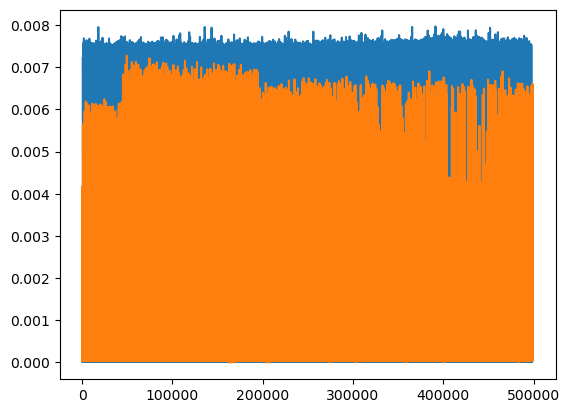

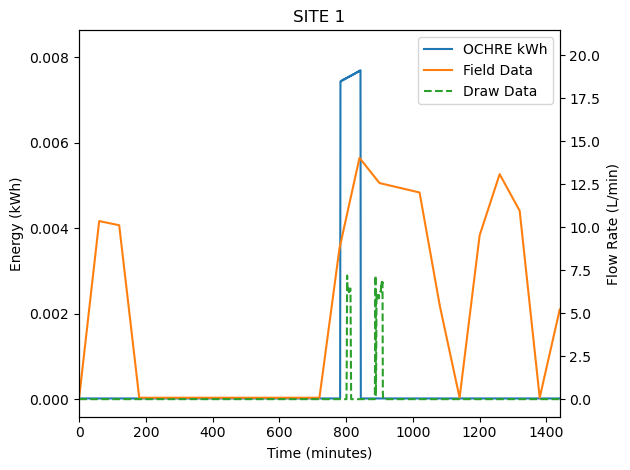

In [46]:
#SECONDARY AXIS
import matplotlib.pyplot as plt

site_number = 1
setpoint = 50.53
file_path = Path(f"output_site_120V_{site_number}_(L)_{setpoint}.csv")
data = pd.read_csv(file_path) #output data
data_ground = pd.read_csv(f'..\\..\\ochre\\defaults\\Input Files\\Temperature Values\\120V_temperatures_{site_number}.csv') #ground truth\



   
# 1. Create the figure and primary axis
fig, ax1 = plt.subplots()

# 2. Plot primary y-axis data (Energy in kWh)
l1 = ax1.plot(
    data["Water Heating Electric Power (kW)"] / 60,
    label="OCHRE kWh",
    color="tab:blue",
)
l2 = ax1.plot(data_ground["HPWH_kWh"], label="Field Data", color="tab:orange")

ax1.set_xlim(0, 1440)
ax1.set_xlabel("Time (minutes)")
ax1.set_ylabel("Energy (kWh)")

# 3. Create secondary axis and plot flow rate
ax2 = ax1.twinx()
l3 = ax2.plot(
    data_ground["flow_L_per_min"],
    label="Draw Data",
    color="tab:green",
    linestyle="--",
)
ax2.set_ylabel("Flow Rate (L/min)")

# 4. Combine legends from both axes into one box
lines = l1 + l2 + l3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper right")
plt.title(f"SITE {site_number}")

plt.tight_layout()
plt.show()

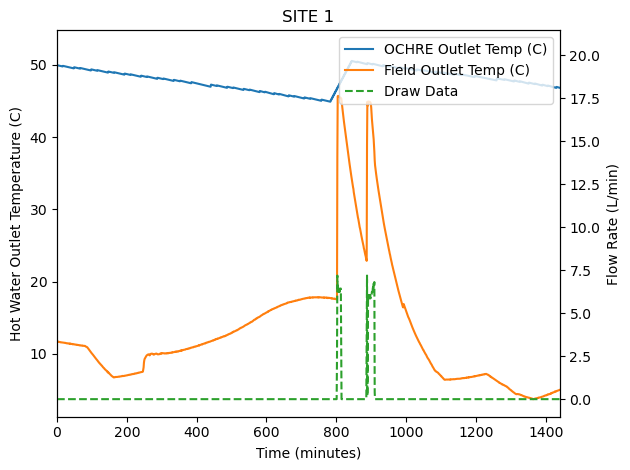

In [47]:
#SECONDARY AXIS
import matplotlib.pyplot as plt

site_number = 1
setpoint = 50.53
file_path = Path(f"output_site_120V_{site_number}_(L)_{setpoint}.csv")
data = pd.read_csv(file_path) #output data
data_ground = pd.read_csv(f'..\\..\\ochre\\defaults\\Input Files\\Temperature Values\\120V_temperatures_{site_number}.csv') #ground truth\



   
# 1. Create the figure and primary axis
fig, ax1 = plt.subplots()

# 2. Plot primary y-axis data (Energy in kWh)
l1 = ax1.plot(
    data["Hot Water Outlet Temperature (C)"],
    label="OCHRE Outlet Temp (C)",
    color="tab:blue",
)
l2 = ax1.plot(data_ground["outlet_C"], label="Field Outlet Temp (C)", color="tab:orange")

ax1.set_xlim(0, 1440)
ax1.set_xlabel("Time (minutes)")
ax1.set_ylabel("Hot Water Outlet Temperature (C)")

# 3. Create secondary axis and plot flow rate
ax2 = ax1.twinx()
l3 = ax2.plot(
    data_ground["flow_L_per_min"],
    label="Draw Data",
    color="tab:green",
    linestyle="--",
)
ax2.set_ylabel("Flow Rate (L/min)")

# 4. Combine legends from both axes into one box
lines = l1 + l2 + l3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper right")
plt.title(f"SITE {site_number}")

plt.tight_layout()
plt.show()

In [42]:
ochre_cumsum

0          0.000
1          0.000
2          0.000
3          0.000
4          0.000
           ...  
498234   210.850
498235   210.850
498236   210.850
498237   210.850
498238   210.850
Name: Water Heating Electric Power (kW), Length: 498239, dtype: float64

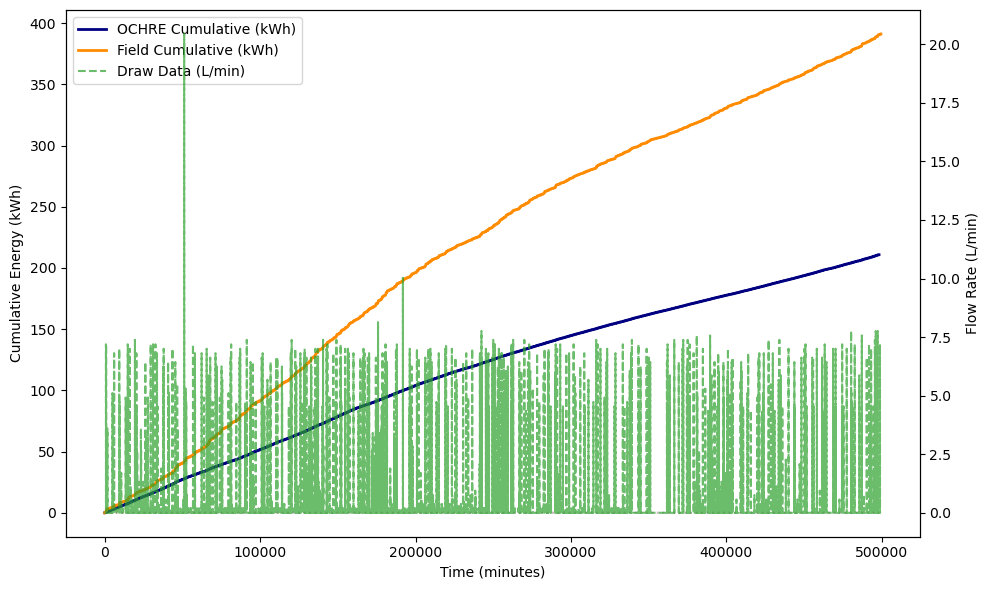

In [43]:
import matplotlib.pyplot as plt

# 1. Calculate cumulative kWh for both datasets
ochre_kwh = data["Water Heating Electric Power (kW)"] / 60
ochre_cumsum = ochre_kwh.cumsum()

field_kwh = data_ground["HPWH_kWh"]
field_cumsum = field_kwh.cumsum()

# 2. Setup figure and primary axis (Energy)
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot cumulative sums
(l1,) = ax1.plot(
    ochre_cumsum, label="OCHRE Cumulative (kWh)", color="navy", linewidth=2
)
(l2,) = ax1.plot(
    field_cumsum,
    label="Field Cumulative (kWh)",
    color="darkorange",
    linewidth=2,
)

# Optional: Plot instantaneous kWh as faint background lines for context
ax1.plot(ochre_kwh, color="blue", alpha=0.25, linestyle=":", label="_nolegend_")
ax1.plot(
    field_kwh, color="orange", alpha=0.25, linestyle=":", label="_nolegend_"
)


ax1.set_xlabel("Time (minutes)")
ax1.set_ylabel("Cumulative Energy (kWh)")

# 3. Setup secondary axis for Water Draw
ax2 = ax1.twinx()
(l3,) = ax2.plot(
    data_ground["flow_L_per_min"],
    label="Draw Data (L/min)",
    color="tab:green",
    linestyle="--",
    alpha=0.7,
)
ax2.set_ylabel("Flow Rate (L/min)")

# 4. Single consolidated legend
lines = [l1, l2, l3]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left")

plt.tight_layout()
plt.show()

In [ ]:
#Compute power error of sites
from pathlib import Path

import pandas as pd
import numpy as np
import pandas as pd


def compute_error(site_number, setpoint):
    file_path = Path(f"output_site_120V_{site_number}_(L)_{setpoint}.csv")

    if not file_path.is_file():  # .is_file() is safer than .exists() as it confirms it's not a folder
            print(f"File not found: {file_path}")
            return

    data = pd.read_csv(file_path) #output data
    data_ground = pd.read_csv(f'..\\..\\ochre\\defaults\\Input Files\\Temperature Values\\120V_temperatures_{site_number}.csv') #ground truth\
    data_raw = pd.read_csv(f'..\\120V_site_raw\site_{site_number}.csv')      
    flow_raw = pd.read_csv(f'..\\..\\ochre\\defaults\\Input Files\\120V_Flow\\net_flow_{site_number}_120V.csv')

    print("Site {site_number} has {n} days of data".format(site_number=site_number, n=len(flow_raw)/1440))

    #daily gallon comparison
    MINUTES_PER_DAY = 1440
    FIFTEEN_MINUTES_PER_DAY = 96

    import numpy as np
    #timezone casting
    ground_electric = pd.DataFrame()
    ground_electric['Time'] = data_raw['local_datetime']
    ground_electric['Time'] = pd.to_datetime(ground_electric['Time'], utc=True)
    ground_electric['HPWH_kw'] = data_raw['HPWH_pwr_kW'] #gets 15 minute time power readings
    data_ground['Time'] = pd.to_datetime(data_ground['Time'], utc=True)

    #derive ground kWh from raw site data

    #perform an inner join to get 15 minute intervals in our flow data
    ground = pd.merge(data_ground, ground_electric, on='Time', how='inner')

    #cast na values to 0
    ground_kw  = pd.to_numeric(ground['HPWH_kw'], errors='coerce').fillna(0).astype(float)
    ground_kw = ground_kw.values

    #Trim outputted data
    daily_flow      = pd.to_numeric(data['Draw Data'], errors='coerce').values
    daily_delivered = pd.to_numeric(data['Hot Water Delivered (kW)'], errors='coerce').values
    electric  = pd.to_numeric(data['Water Heating Electric Power (kW)'], errors='coerce').values

    # Trim to a multiple of 1440 (drops incomplete trailing day)
    n_days = len(daily_flow) // MINUTES_PER_DAY
    n_days = n_days - 15#

    daily_flow      = daily_flow[:n_days * MINUTES_PER_DAY].reshape(n_days, MINUTES_PER_DAY).sum(axis=1)
    daily_delivered = daily_delivered[:n_days * MINUTES_PER_DAY].reshape(n_days, MINUTES_PER_DAY).sum(axis=1) /60 #kWh
    daily_electric  = electric[:n_days * MINUTES_PER_DAY].reshape(n_days, MINUTES_PER_DAY).sum(axis=1) /60 #kWh
    ground_kwh = ground_kw[0:n_days * FIFTEEN_MINUTES_PER_DAY].reshape(n_days, FIFTEEN_MINUTES_PER_DAY).sum(axis=1) / 4  #kWh

    n_days

    e = daily_electric[60:-7]
    g = ground_kwh[60:-7]

    if site_number in [1, 2, 3, 5, 8, 15, 19, 21, 22, 25, 27, 28]:
        e = daily_electric[60:-7]
        g = ground_kwh[60:-7]

    diff = g - e

    def pct(a, p):
        return np.percentile(a, p)
    
    print(f"Site {site_number}")

    mae  = np.mean(np.abs(diff))
    rmse = np.sqrt(np.mean(diff**2))
    mape = np.mean(np.abs(diff / (g + 1e-9))) * 100
    r2   = 1 - np.sum(diff**2) / np.sum((g - g.mean())**2)

    stats = pd.DataFrame({
        'Metric': [
            'Total energy (kWh)',
            'Mean (kWh/day)', 'Std dev', 'Min',
            'Median (p50)', 'p75', 'p90', 'Max',
            '— MAE', '— RMSE', '— MAPE (%)', '— R²',
        ],
        'Simulated': [
            e.sum(),
            e.mean(), e.std(), e.min(),
            pct(e,50), pct(e,75), pct(e,90), e.max(),
            mae, rmse, mape, r2,
        ],
        'Ground truth': [
            g.sum(),
            g.mean(), g.std(), g.min(),
            pct(g,50), pct(g,75), pct(g,90), g.max(),
            None, None, None, None,
        ],
        'Difference (GT − Sim)': [
            g.sum()-e.sum(),
            g.mean()-e.mean(), g.std()-e.std(), g.min()-e.min(),
            pct(g,50)-pct(e,50), pct(g,75)-pct(e,75),
            pct(g,90)-pct(e,90), g.max()-e.max(),
            None, None, None, None,
        ],
    }).set_index('Metric')

    pd.set_option('display.float_format', '{:.3f}'.format)
    print(stats.to_string())
    percent_error = (g.sum()-e.sum())/g.sum() * 100
    print(f"Percent Error: {percent_error:.3f}%")
    return percent_error

G_PER_L = 0.26417205
def compute_avg_gallons(site_number, setpoint):
    file_path = Path(f"output_site_120V_{site_number}_(L)_{setpoint}.csv")

    if not file_path.is_file():  # .is_file() is safer than .exists() as it confirms it's not a folder
            print(f"File not found: {file_path}")
            return

    data = pd.read_csv(file_path) #output data

    #daily gallon comparison
    MINUTES_PER_DAY = 1440

    # Trim to a multiple of 1440 (drops incomplete trailing day)
    n_days = len(data['Draw Data']) // MINUTES_PER_DAY

    daily_flow = data['Draw Data'].values
    daily_flow = daily_flow[:n_days * MINUTES_PER_DAY].reshape(n_days, MINUTES_PER_DAY).sum(axis=1)
    daily_flow = daily_flow * G_PER_L
    return np.mean(daily_flow)


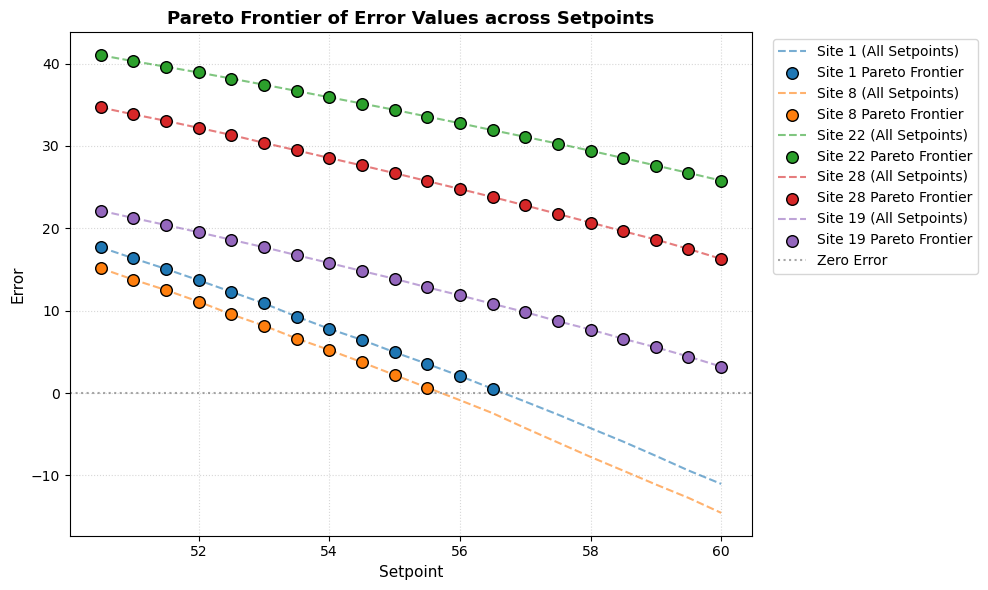

In [5]:
import matplotlib.pyplot as plt
def find_pareto_frontier(costs):
    """Calculates boolean mask for Pareto efficient (non-dominated) points.

    'costs' is an (N, 2) array where we aim to MINIMIZE both columns.
    """
    is_efficient = np.ones(costs.shape[0], dtype=bool)
    for i, c in enumerate(costs):
        if is_efficient[i]:
            # Keep points that are strictly better in at least one objective
            is_efficient[is_efficient] = np.any(
                costs[is_efficient] < c, axis=1
            ) | np.all(costs[is_efficient] == c, axis=1)
            is_efficient[i] = True
    return is_efficient


# 2. Plotting Setup
plt.figure(figsize=(10, 6))

for site_id, errors in cumulative_error.items():
    x = np.arange(50.5, 60.5, 0.5)
    y_raw = np.array(errors)
    y_abs = np.abs(y_raw)  

    # Matrix of objectives: [Setpoint, Absolute Error]
    objectives = np.column_stack((x, y_abs))
    pareto_mask = find_pareto_frontier(objectives)

    # Plot full error trajectory
    line = plt.plot(
        x,
        y_raw,
        label=f"Site {site_id} (All Setpoints)",
        linestyle="--",
        alpha=0.6,
    )

    # Highlight Pareto optimal points
    plt.scatter(
        x[pareto_mask],
        y_raw[pareto_mask],
        color=line[0].get_color(),
        s=70,
        edgecolor="black",
        linewidth=1,
        label=f"Site {site_id} Pareto Frontier",
        zorder=5,
    )

plt.axhline(0, color="gray", linestyle=":", alpha=0.7, label="Zero Error")
plt.xlabel("Setpoint", fontsize=11)
plt.ylabel("Error", fontsize=11)
plt.title(
    "Pareto Frontier of Error Values across Setpoints",
    fontsize=13,
    fontweight="bold",
)
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [28]:
cumulative_error

NameError: name 'cumulative_error' is not defined

In [23]:
#For each High error site, re-run compute error on setpoints
from collections import defaultdict
#compare 120 v data output

site_setpoints = {
    1: 50.53, 2:48.82, 3:52.27, 4:49.52, 5:60, 7:49.35, 8:50.54, 9:48.34, 10:49.07, 11:50, 12:49.06, 13:49.28, 14:50.96, 15:51.43, 16:53.15, 18:48.53, 19:58.11, 21:50.16, 22:56.71, 23:51.12, 24:50.75, 25:51.22, 27:51.05, 28:51.6, 29:49.75, 30:50.75
}

cumulative_error =  defaultdict(list)
cumulative_setpoints= {}
avg_gallons = {}
for site_number in range(2, 31):

    if site_number in [1, 3, 5, 7,  8, 14, 15, 16, 18, 19, 21, 22, 23, 24, 25, 27, 28, 29, 30]:      
        error = compute_error(site_number, site_setpoints[site_number])
    else:
        error = compute_error(site_number, 48.9)
    if error is not None:
        cumulative_error[site_number].append(error)


for error in cumulative_error.values():
    print(f"Individual Error: {error:.3f}%")
print(f"Average Percent Error: {np.mean(list(cumulative_error.values())):.3f}%")



C:\Users\m10950449\AppData\Local\Temp\ipykernel_34764\4246460158.py:18: DtypeWarning: Columns (46,50,55) have mixed types. Specify dtype option on import or set low_memory=False.
  data_raw = pd.read_csv(f'..\\120V_site_raw\site_{site_number}.csv')


Site 2 has 372.34444444444443 days of data


ValueError: operands could not be broadcast together with shapes (207,) (267,) 

In [54]:
cumulative_error

defaultdict(list,
            {1: [17.633532849837387],
             2: [22.303511102071138],
             3: [4.645770485675032],
             4: [5.562886923683117],
             5: [-12.995215594114546],
             7: [-8.980726935538597],
             8: [15.044816266516008],
             9: [10.057722604720874],
             10: [-4.004418290838617],
             11: [15.879235836697648],
             12: [9.627028895433527],
             14: [-8.860633350674854],
             15: [5.435609009444134],
             16: [1.9169459783942184],
             19: [7.468640892149744],
             21: [28.48080728908372],
             22: [31.57138266163702],
             23: [23.78290369799775],
             24: [32.98137016281967],
             25: [25.731898435534333],
             27: [22.550447972280494],
             28: [32.87015059710598],
             30: [7.8749477763623235]})

In [48]:
#compare 120 v data output

cumulative_error = {}
avg_gallons = {}
for site_number in range(1, 31):
    setpoint = 48.9

    if site_number in [1, 3, 8, 15, 19, 21, 22, 25, 27, 28]:
        setpoint = 50
    if site_number in [19, 22]:
        setpoint = 55
    if site_number == 23:
        setpoint = 51.67
    if site_number == 24:
        setpoint = 60
    
    error = compute_error(site_number, setpoint)
    if error is not None:
        cumulative_error[site_number] = error
        avg_gallons[site_number] = compute_avg_gallons(site_number, setpoint)

for error in cumulative_error.values():
    print(f"Individual Error: {error:.3f}%")
print(f"Average Percent Error: {np.mean(list(cumulative_error.values())):.3f}%")



C:\Users\m10950449\AppData\Local\Temp\ipykernel_7080\1998413583.py:17: DtypeWarning: Columns (46,50,55) have mixed types. Specify dtype option on import or set low_memory=False.
  data_raw = pd.read_csv(f'..\\120V_site_raw\site_{site_number}.csv')


Site 1 has 360.9222222222222 days of data
Site 1
                    Simulated  Ground truth  Difference (GT − Sim)
Metric                                                            
Total energy (kWh)    234.720       289.510                 54.790
Mean (kWh/day)          0.892         1.101                  0.208
Std dev                 0.444         0.634                  0.190
Min                     0.373         0.322                 -0.051
Median (p50)            0.810         0.889                  0.079
p75                     1.078         1.390                  0.312
p90                     1.553         2.011                  0.458
Max                     2.439         3.696                  1.256
— MAE                   0.301           NaN                    NaN
— RMSE                  0.402           NaN                    NaN
— MAPE (%)             26.941           NaN                    NaN
— R²                    0.598           NaN                    NaN
Percent Error

C:\Users\m10950449\AppData\Local\Temp\ipykernel_7080\1998413583.py:17: DtypeWarning: Columns (46,50,55) have mixed types. Specify dtype option on import or set low_memory=False.
  data_raw = pd.read_csv(f'..\\120V_site_raw\site_{site_number}.csv')


Site 2 has 372.34444444444443 days of data
Site 2
                    Simulated  Ground truth  Difference (GT − Sim)
Metric                                                            
Total energy (kWh)    629.302       809.949                180.647
Mean (kWh/day)          2.357         3.034                  0.677
Std dev                 1.149         1.350                  0.201
Min                     0.675         0.536                 -0.139
Median (p50)            2.246         3.015                  0.769
p75                     3.098         3.973                  0.874
p90                     3.958         4.879                  0.921
Max                     6.847         6.824                 -0.023
— MAE                   1.384           NaN                    NaN
— RMSE                  1.749           NaN                    NaN
— MAPE (%)             50.288           NaN                    NaN
— R²                   -0.678           NaN                    NaN
Percent Erro

C:\Users\m10950449\AppData\Local\Temp\ipykernel_7080\1998413583.py:17: DtypeWarning: Columns (46,50,55) have mixed types. Specify dtype option on import or set low_memory=False.
  data_raw = pd.read_csv(f'..\\120V_site_raw\site_{site_number}.csv')


...

Site 23 has 278.7895833333333 days of data
Site 23
                    Simulated  Ground truth  Difference (GT − Sim)
Metric                                                            
Total energy (kWh)    359.833       466.601                106.767
Mean (kWh/day)          1.884         2.443                  0.559
Std dev                 0.717         0.771                  0.053
Min                     0.505         0.382                 -0.122
Median (p50)            1.735         2.330                  0.596
p75                     2.253         2.895                  0.643
p90                     2.933         3.519                  0.586
Max                     4.159         5.365                  1.206
— MAE                   0.668           NaN                    NaN
— RMSE                  0.805           NaN                    NaN
— MAPE (%)             27.571           NaN                    NaN
— R²                   -0.091           NaN                    NaN
Percent Err

C:\Users\m10950449\AppData\Local\Temp\ipykernel_7080\1998413583.py:17: DtypeWarning: Columns (46,50,55) have mixed types. Specify dtype option on import or set low_memory=False.
  data_raw = pd.read_csv(f'..\\120V_site_raw\site_{site_number}.csv')


Site 24 has 279.72430555555553 days of data
Site 24
                    Simulated  Ground truth  Difference (GT − Sim)
Metric                                                            
Total energy (kWh)    449.442       547.159                 97.717
Mean (kWh/day)          2.353         2.865                  0.512
Std dev                 0.927         0.936                  0.010
Min                     1.031         1.093                  0.062
Median (p50)            2.111         2.617                  0.506
p75                     2.808         3.389                  0.580
p90                     3.701         4.436                  0.735
Max                     6.068         5.623                 -0.445
— MAE                   0.584           NaN                    NaN
— RMSE                  0.702           NaN                    NaN
— MAPE (%)             20.807           NaN                    NaN
— R²                    0.438           NaN                    NaN
Percent Er

C:\Users\m10950449\AppData\Local\Temp\ipykernel_7080\1998413583.py:17: DtypeWarning: Columns (46,50,55) have mixed types. Specify dtype option on import or set low_memory=False.
  data_raw = pd.read_csv(f'..\\120V_site_raw\site_{site_number}.csv')


Site 30 has 248.72152777777777 days of data
Site 30
                    Simulated  Ground truth  Difference (GT − Sim)
Metric                                                            
Total energy (kWh)    159.822       182.295                 22.473
Mean (kWh/day)          0.975         1.112                  0.137
Std dev                 0.427         0.534                  0.107
Min                     0.358         0.046                 -0.312
Median (p50)            0.918         1.125                  0.207
p75                     1.130         1.375                  0.245
p90                     1.284         1.593                  0.310
Max                     3.341         3.622                  0.281
— MAE                   0.287           NaN                    NaN
— RMSE                  0.363           NaN                    NaN
— MAPE (%)             78.870           NaN                    NaN
— R²                    0.537           NaN                    NaN
Percent Er

In [56]:
cumulative_error

data = [cumulative_error[item][0] for item in cumulative_error]
data

cumulative_error

defaultdict(list,
            {1: [17.633532849837387],
             2: [22.303511102071138],
             3: [4.645770485675032],
             4: [5.562886923683117],
             5: [-12.995215594114546],
             7: [-8.980726935538597],
             8: [15.044816266516008],
             9: [10.057722604720874],
             10: [-4.004418290838617],
             11: [15.879235836697648],
             12: [9.627028895433527],
             14: [-8.860633350674854],
             15: [5.435609009444134],
             16: [1.9169459783942184],
             19: [7.468640892149744],
             21: [28.48080728908372],
             22: [31.57138266163702],
             23: [23.78290369799775],
             24: [32.98137016281967],
             25: [25.731898435534333],
             27: [22.550447972280494],
             28: [32.87015059710598],
             30: [7.8749477763623235]})

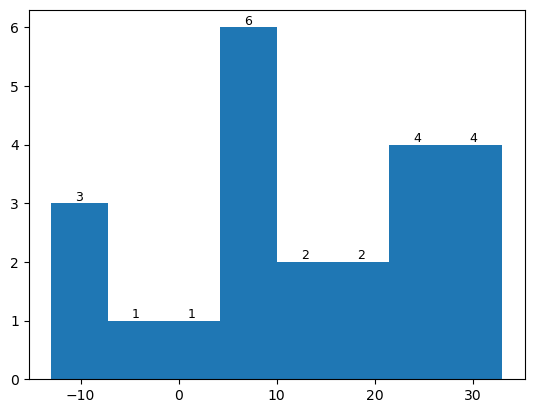

In [57]:
import matplotlib.pyplot as plt

#data = cumulative_error.values()  # your 1D array/list

counts, bins, patches = plt.hist(data, bins=8)

for p in patches:
    h = p.get_height()
    if h == 0:
        continue
    x = p.get_x() + p.get_width() / 2
    plt.text(x, h, f"{int(h)}", ha="center", va="bottom", fontsize=9)

plt.show()

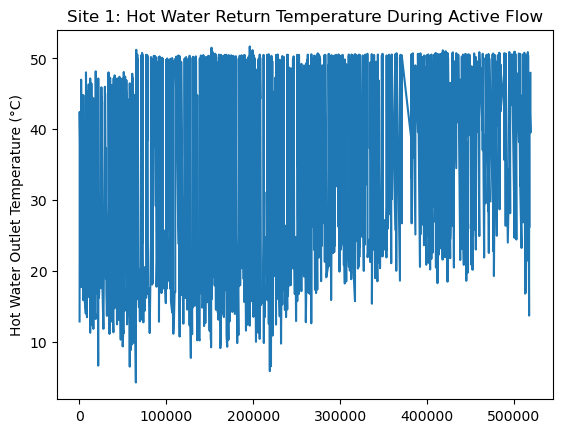

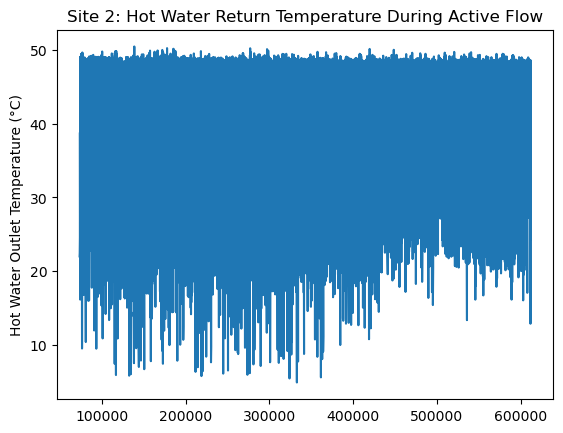

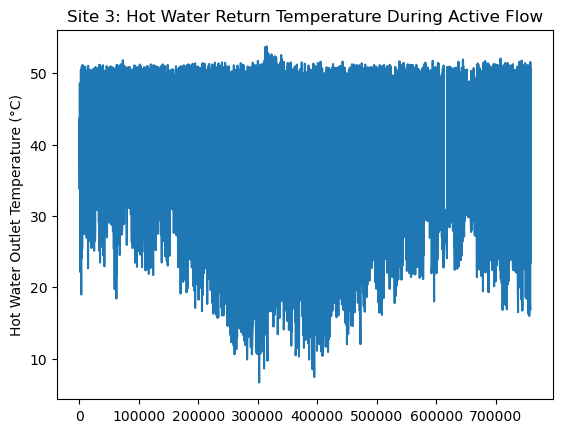

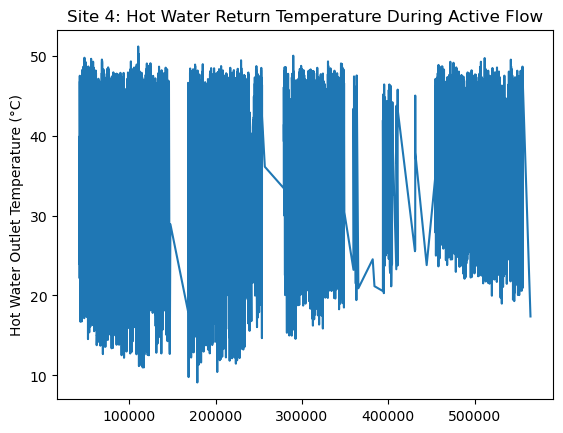

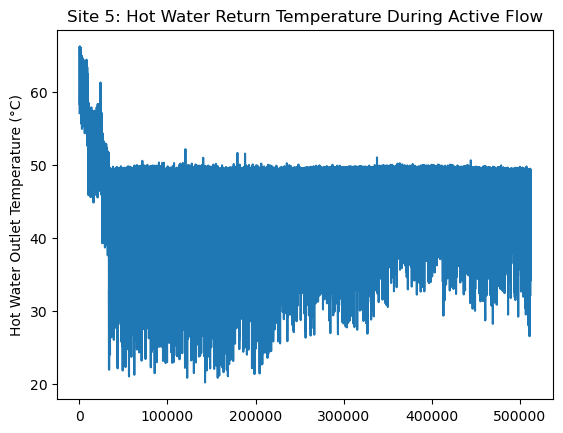

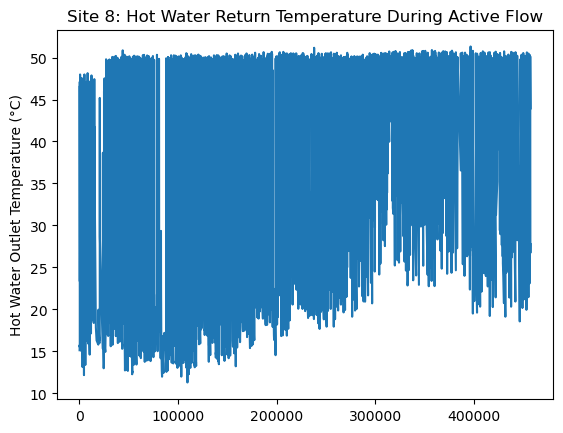

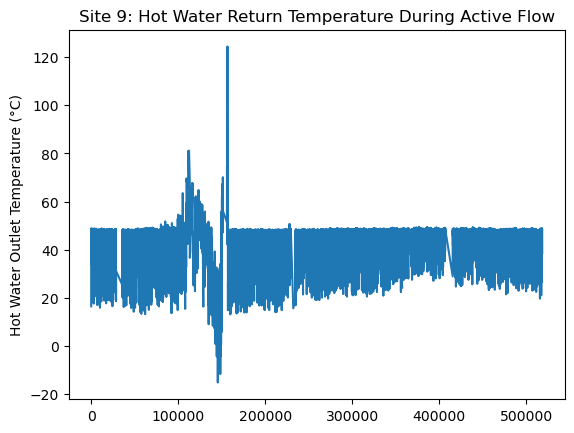

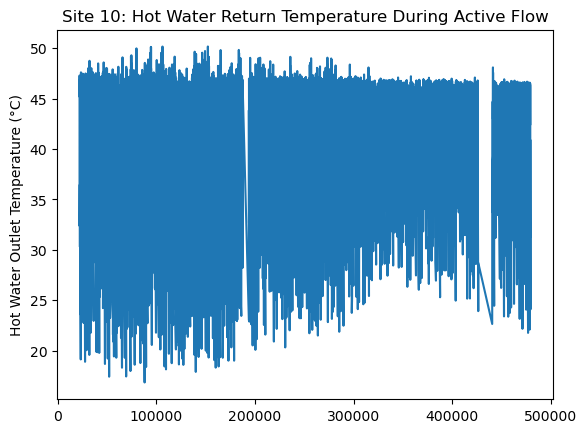

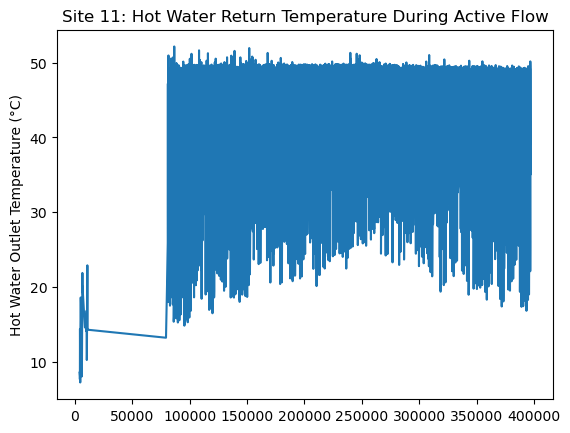

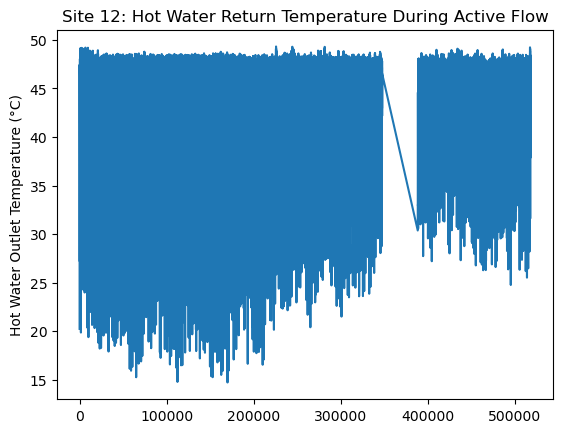

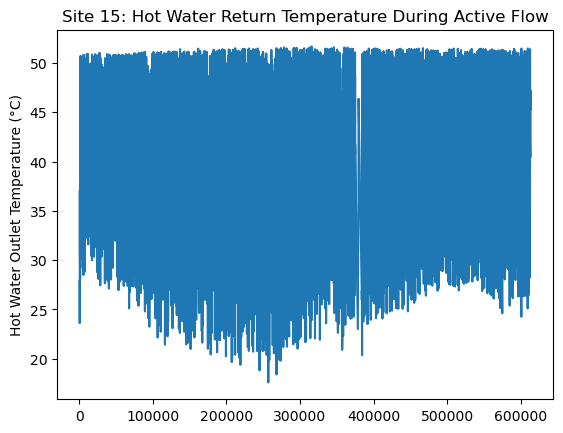

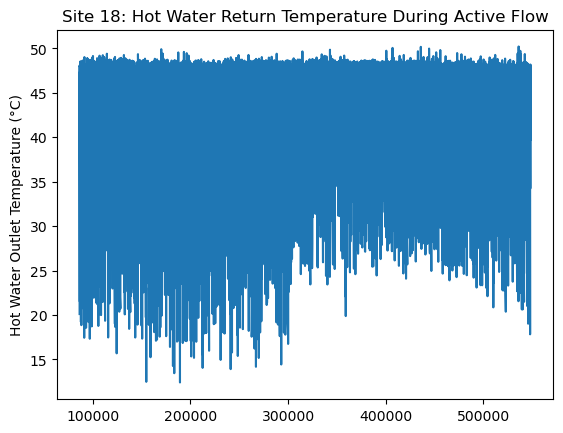

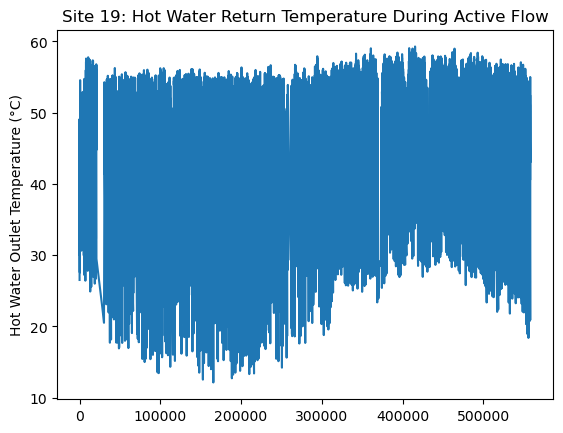

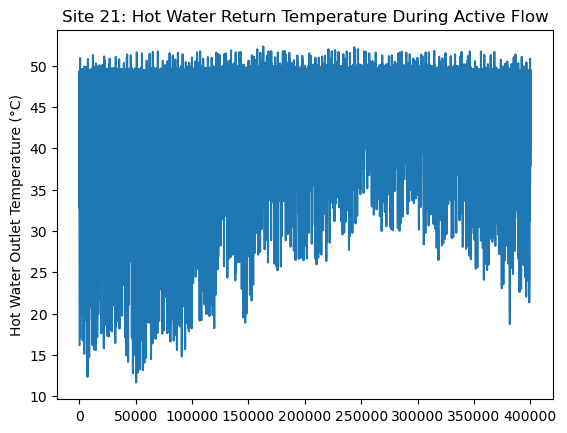

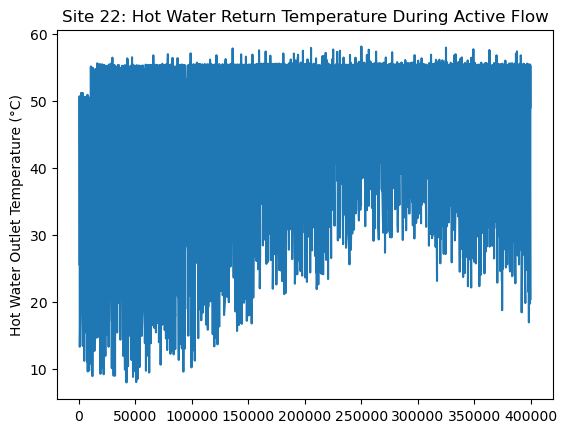

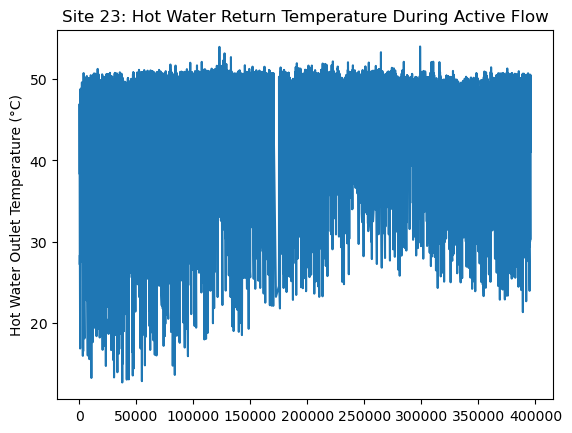

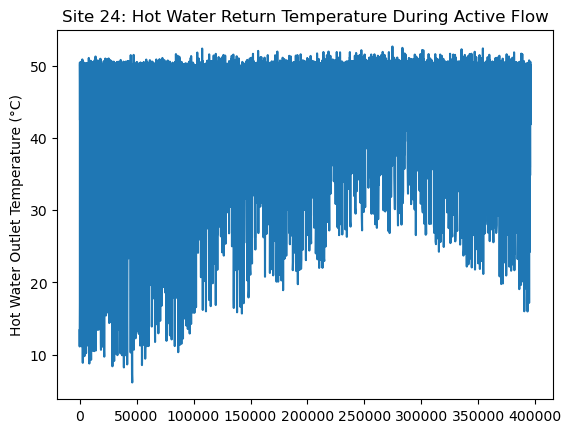

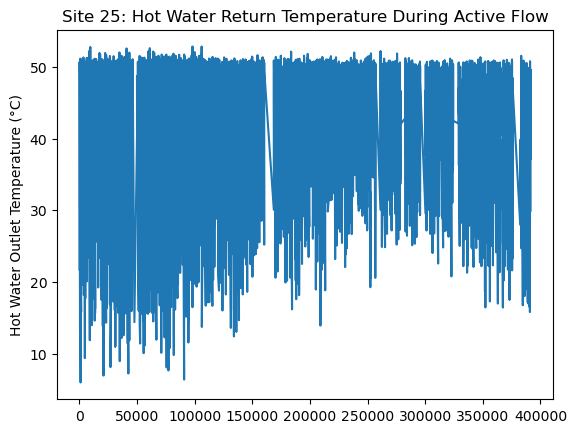

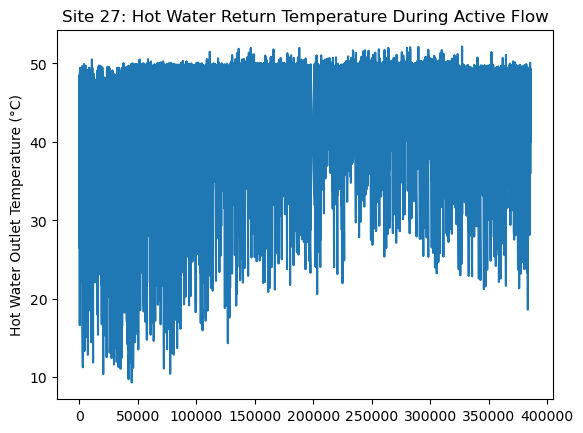

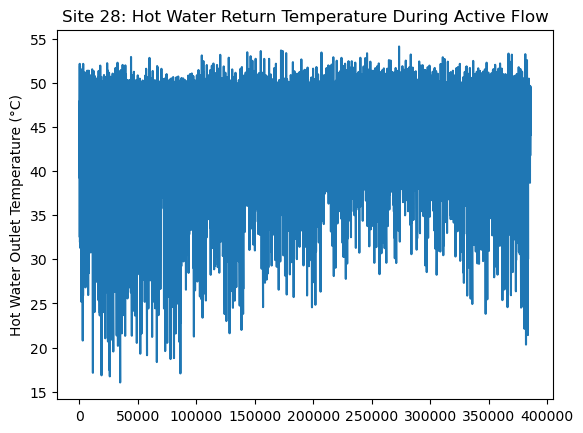

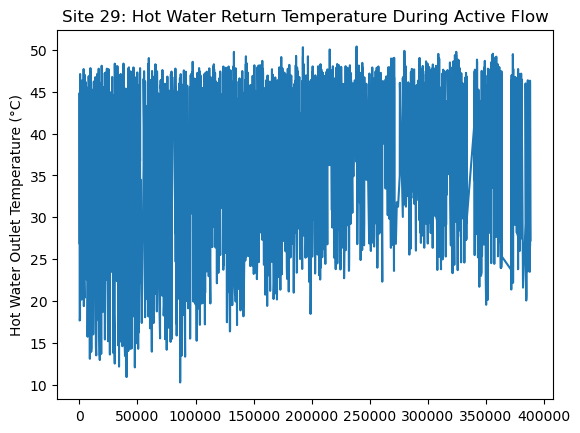

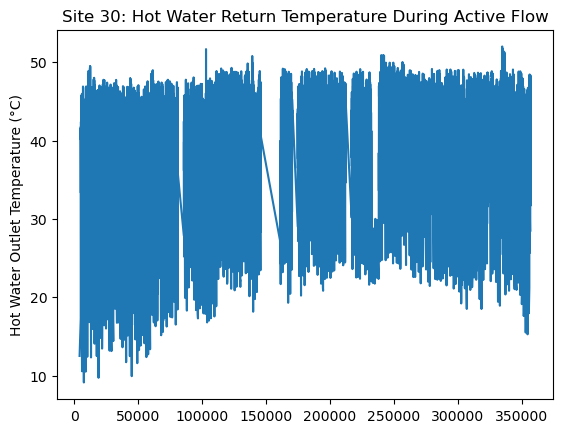

Text(0, 0.5, 'Daily Calculated Energy Factor')

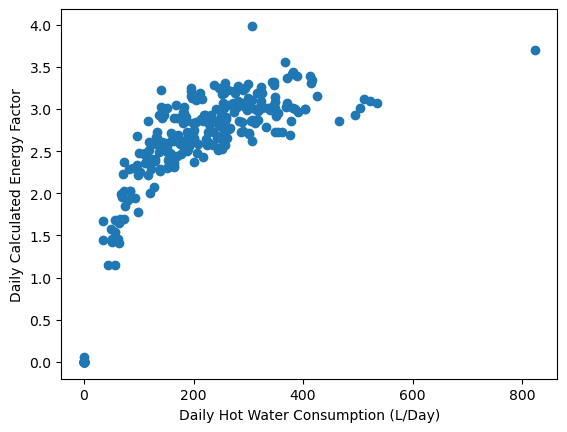

In [86]:
import matplotlib.pyplot as plt

plt.scatter(daily_flow, daily_delivered/daily_electric)
plt.xlabel("Daily Hot Water Consumption (L/Day)")
plt.ylabel("Daily Calculated Energy Factor")

In [46]:
ground_pwr[:n_days * MINUTES_PER_DAY].reshape(n_days, MINUTES_PER_DAY).sum(axis=1)


AttributeError: 'Series' object has no attribute 'reshape'

C:\Users\m10950449\AppData\Local\Temp\ipykernel_129992\1659476597.py:8: DtypeWarning: Columns (46,50,55) have mixed types. Specify dtype option on import or set low_memory=False.
  data_raw = pd.read_csv(f'..\\120V_site_raw\site_{site_number}.csv')


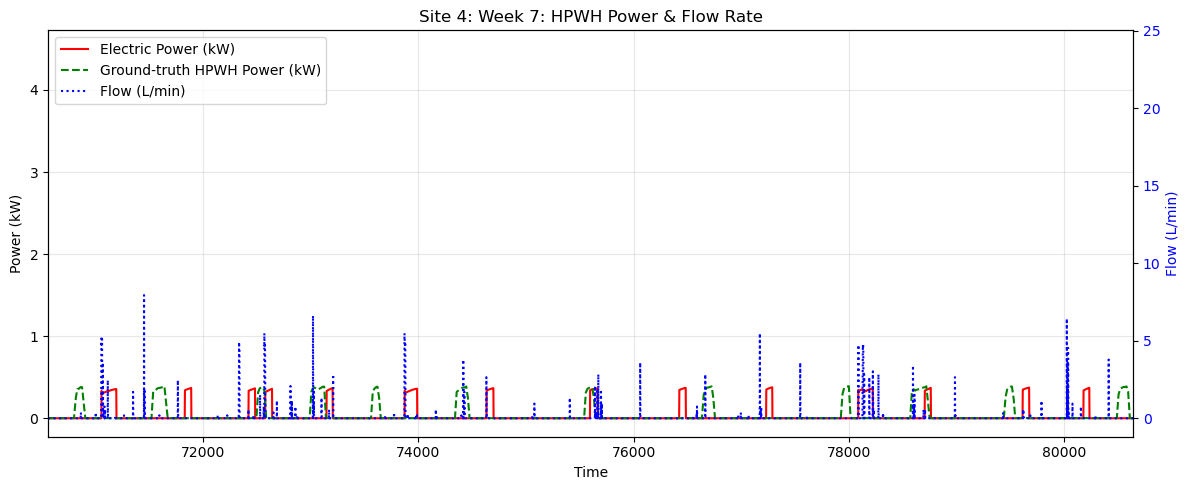

In [13]:
setpoint = 48.9
site_number = 4
MINUTES_PER_DAY = 24 * 60


data = pd.read_csv(f"output_site_120V_{site_number}_(L)_{setpoint}.csv") #output data
data_ground = pd.read_csv(f'..\\..\\ochre\\defaults\\Input Files\\Temperature Values\\120V_temperatures_{site_number}.csv') #ground truth
data_raw = pd.read_csv(f'..\\120V_site_raw\site_{site_number}.csv')      
flow_raw = pd.read_csv(f'..\\..\\ochre\\defaults\\Input Files\\120V_Flow\\net_flow_{site_number}_120V.csv')


#Trim outputted data
daily_flow      = data['Draw Data'].values
daily_delivered = data['Hot Water Delivered (kW)'].values
electric  = data['Water Heating Electric Power (kW)'].values
ground_pwr = data_ground['HPWH_pwr_kW'].values

# Trim to a multiple of 1440 (drops incomplete trailing day)
n_days = len(daily_flow) // MINUTES_PER_DAY
n_days = n_days#


daily_flow      = daily_flow[:n_days * MINUTES_PER_DAY].reshape(n_days, MINUTES_PER_DAY).sum(axis=1)
daily_delivered = daily_delivered[:n_days * MINUTES_PER_DAY].reshape(n_days, MINUTES_PER_DAY).sum(axis=1) /60 #kWh
daily_electric  = electric[:n_days * MINUTES_PER_DAY].reshape(n_days, MINUTES_PER_DAY).sum(axis=1) /60 #kWh
ground_kwh = ground_pwr[:n_days * MINUTES_PER_DAY].reshape(n_days, MINUTES_PER_DAY).sum(axis=1) /60


flow = data_ground['flow_L_per_min']


import pandas as pd
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt

day = 0
week = 7
month = 0
data_len = len(data.index)

fig, ax1 = plt.subplots(figsize=(12, 5))

# Primary axis - power variables

#ax1.plot(data_backup.index, backup_pwr, color='orange', label='Hot Water Delivered (kW)')
ax1.plot(data.index, data['Water Heating Electric Power (kW)'], color='red', label='Electric Power (kW)')
ax1.plot(data.index, ground_pwr[0:data_len], color='green', label='Ground-truth HPWH Power (kW)', linestyle='dashed')
ax1.set_ylabel('Power (kW)')
ax1.set_xlabel('Time')
ax1.grid(True, alpha=0.3)

# Secondary axis - flow
ax2 = ax1.twinx()
ax2.plot(data.index, data['Draw Data'], color='blue', label='Flow (L/min)', linestyle='dotted')
ax2.set_ylabel('Flow (L/min)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_xlim(week * 7 * MINUTES_PER_DAY, week * 7 * MINUTES_PER_DAY +  7 * MINUTES_PER_DAY)

plt.title(f'Site {site_number}: Week {week}: HPWH Power & Flow Rate')

# ax1.set_xlim(month * 30 * MINUTES_PER_DAY, month * 30 *  MINUTES_PER_DAY +   30 * MINUTES_PER_DAY)

# plt.title(f'Site {site_number}: Month {month}: HPWH Power & Flow Rate')

plt.tight_layout()
plt.show()

# Daily Aggregates


C:\Users\m10950449\AppData\Local\Temp\ipykernel_58544\3687483461.py:8: DtypeWarning: Columns (46,50,55) have mixed types. Specify dtype option on import or set low_memory=False.
  data_raw = pd.read_csv(f'120V_site_raw\site_{site_number}.csv')


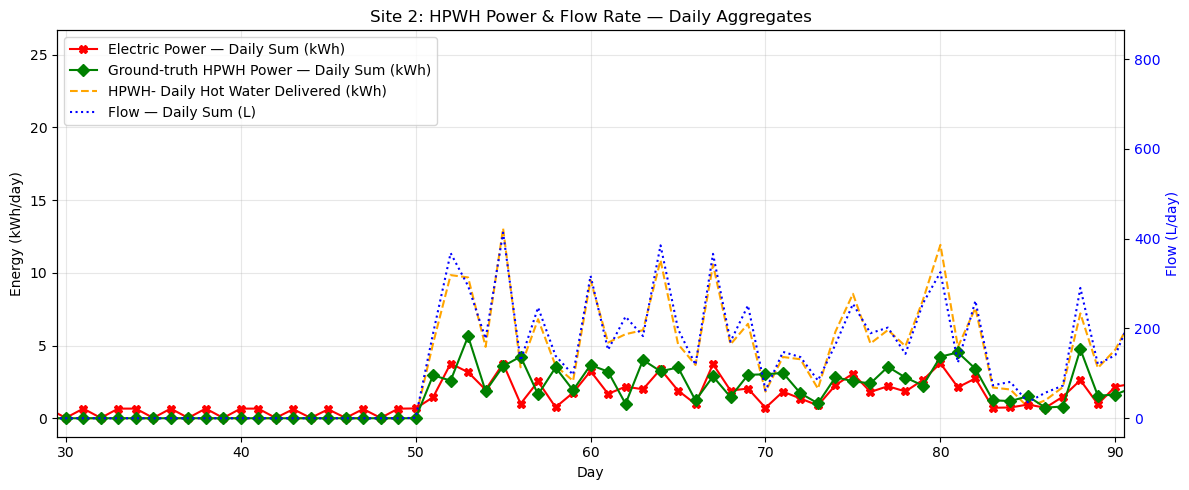

In [121]:
setpoint = 48.9
site_number = 2
MINUTES_PER_DAY = 24 * 60


data = pd.read_csv(f"120V_site_output\\output_site_120V_{site_number}_(L)_{setpoint}.csv") #output data
data_ground = pd.read_csv(f'..\\ochre\\defaults\\Input Files\\Temperature Values\\120V_temperatures_{site_number}.csv') #ground truth
data_raw = pd.read_csv(f'120V_site_raw\site_{site_number}.csv')      
flow_raw = pd.read_csv(f'..\\ochre\\defaults\\Input Files\\120V_Flow\\net_flow_{site_number}_120V.csv')


#Trim outputted data
daily_flow      = data['Draw Data'].values
daily_delivered = data['Hot Water Delivered (kW)'].values
electric  = data['Water Heating Electric Power (kW)'].values
ground_pwr = data_ground['HPWH_pwr_kW'].values

# Trim to a multiple of 1440 (drops incomplete trailing day)
n_days = len(daily_flow) // MINUTES_PER_DAY
n_days = n_days#


daily_flow      = daily_flow[:n_days * MINUTES_PER_DAY].reshape(n_days, MINUTES_PER_DAY).sum(axis=1)
daily_delivered = daily_delivered[:n_days * MINUTES_PER_DAY].reshape(n_days, MINUTES_PER_DAY).sum(axis=1) /60 #kWh
daily_electric  = electric[:n_days * MINUTES_PER_DAY].reshape(n_days, MINUTES_PER_DAY).sum(axis=1) /60 #kWh
ground_kwh = ground_pwr[:n_days * MINUTES_PER_DAY].reshape(n_days, MINUTES_PER_DAY).sum(axis=1) /60


flow = data_ground['flow_L_per_min']

import pandas as pd
import matplotlib.pyplot as plt

day = 0
week = 0
month = 1
data_len = len(data.index)

# --- Aggregate to daily sums ---
MINUTES_PER_DAY = 1440


# Filter to the selected month
day_start = month * 30
day_end   = day_start + 60

days_index = range(len(daily_electric))


fig, ax1 = plt.subplots(figsize=(12, 5))

# Primary axis - power (daily sums)
ax1.plot(days_index, daily_electric,   color='red',   label='Electric Power — Daily Sum (kWh)', marker='X',       zorder=3)
ax1.plot(days_index, ground_kwh, color='green', label='Ground-truth HPWH Power — Daily Sum (kWh)',
            marker='D', zorder=3)
ax1.plot(days_index, daily_delivered, label="HPWH- Daily Hot Water Delivered (kWh)", color="orange", linestyle="dashed")
ax1.set_ylabel('Energy (kWh/day)')
ax1.set_xlabel('Day')
ax1.grid(True, alpha=0.3)

# Secondary axis - flow (daily sum)
ax2 = ax1.twinx()
ax2.plot(days_index, daily_flow, color='blue', label='Flow — Daily Sum (L)', linestyle="dotted", zorder=3)
ax2.set_ylabel('Flow (L/day)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_xlim(day_start - 0.5, day_end + 0.5)
plt.title(f'Site {site_number}: HPWH Power & Flow Rate — Daily Aggregates')
plt.tight_layout()
plt.show()

In [13]:
import numpy as np
import pandas as pd

e = elec_daily
g = ground_daily

diff = g - e

def pct(a, p):
    return np.percentile(a, p)

mae  = np.mean(np.abs(diff))
rmse = np.sqrt(np.mean(diff**2))
mape = np.mean(np.abs(diff / (g + 1e-9))) * 100
r2   = 1 - np.sum(diff**2) / np.sum((g - g.mean())**2)

stats = pd.DataFrame({
    'Metric': [
        'Total energy (kWh)',
        'Mean (kWh/day)', 'Std dev', 'Min',
        'Median (p50)', 'p75', 'p90', 'Max',
        '— MAE', '— RMSE', '— MAPE (%)', '— R²',
    ],
    'Simulated': [
        e.sum(),
        e.mean(), e.std(), e.min(),
        pct(e,50), pct(e,75), pct(e,90), e.max(),
        mae, rmse, mape, r2,
    ],
    'Ground truth': [
        g.sum(),
        g.mean(), g.std(), g.min(),
        pct(g,50), pct(g,75), pct(g,90), g.max(),
        None, None, None, None,
    ],
    'Difference (GT − Sim)': [
        g.sum()-e.sum(),
        g.mean()-e.mean(), g.std()-e.std(), g.min()-e.min(),
        pct(g,50)-pct(e,50), pct(g,75)-pct(e,75),
        pct(g,90)-pct(e,90), g.max()-e.max(),
        None, None, None, None,
    ],
}).set_index('Metric')

pd.set_option('display.float_format', '{:.3f}'.format)
print(stats.to_string())

NameError: name 'elec_daily' is not defined

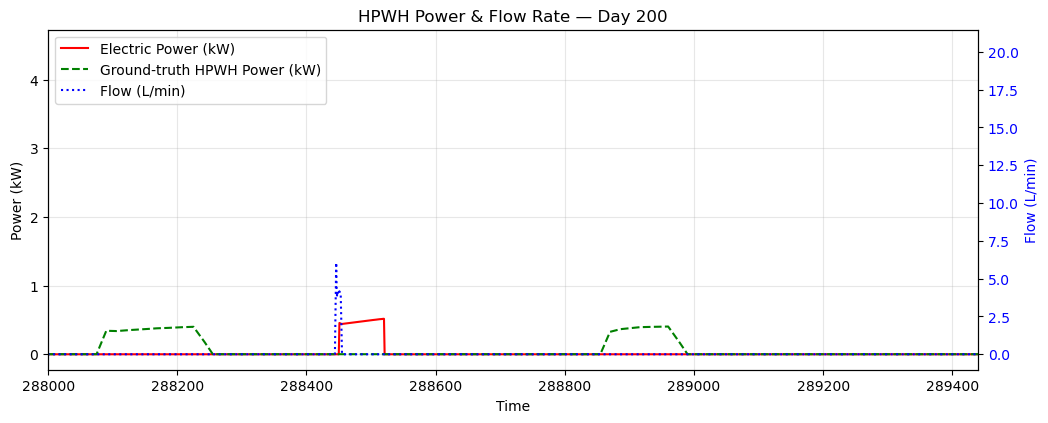

In [90]:
from matplotlib.widgets import Slider
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 5))
plt.subplots_adjust(bottom=0.2)  # make room for slider

data_len = len(data.index)

def get_xlim(day):
    return day * MINUTES_PER_DAY, day * MINUTES_PER_DAY + MINUTES_PER_DAY

# Initial day
day = 200

line_elec, = ax1.plot(data.index, data['Water Heating Electric Power (kW)'], color='red', label='Electric Power (kW)')
line_ground, = ax1.plot(data.index, ground_pwr[0:data_len], color='green', label='Ground-truth HPWH Power (kW)', linestyle='dashed')
ax1.set_ylabel('Power (kW)')
ax1.set_xlabel('Time')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
line_flow, = ax2.plot(data.index, data['Draw Data'], color='blue', label='Flow (L/min)', linestyle='dotted')
ax2.set_ylabel('Flow (L/min)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax1.set_xlim(*get_xlim(day))
title = plt.title(f'HPWH Power & Flow Rate — Day {day}')



In [51]:
#2 node simulation
import os
import datetime as dt
import pandas as pd
import numpy as np

from ochre import Dwelling
from ochre.utils import default_input_path  # for using sample files
from ochre import HeatPumpWaterHeater

import datetime as dt
start_date = dt.datetime(2013, 2, 5, 0, 0) 
setpoint_default = 51  # in C #alternate b/w 60 and 49
deadband_default = 5.56  # in C

def predict_two_node(temp_n1, temp_n2, setpoint, draw):
    setpoint_default = setpoint
    equipment_args = {
        "start_time": start_date,  # year, month, day, hour, minute
        "time_res": dt.timedelta(minutes=1),
        "duration": dt.timedelta(minutes = len(draw)),
        "verbosity": 9,  # required to get setpoint and deadband in results
        "save_results": False,  # if True, must specify output_path
        # "output_path": os.getcwd(),        # Equipment parameters
        "Setpoint Temperature (C)": setpoint_default,
        "Tank Volume (L)": 250,
        "Tank Height (m)": 1.22,
        "UA (W/K)": 2.17,
        "HPWH COP (-)": 4.5,
        "water_nodes": 2
    }

    # Create water draw schedule
    times = pd.date_range(
        equipment_args["start_time"],
        equipment_args["start_time"] + equipment_args["duration"],
        freq=equipment_args["time_res"],
        inclusive="left",
    )
    #withdraw_rate = np.random.choice([0, water_draw_magnitude], p=[0.99, 0.01], size=len(times))
    withdraw_rate = draw
    withdraw_rate = withdraw_rate[:len(times)]
    schedule = pd.DataFrame(
        {
            "Water Heating (L/min)": withdraw_rate,
            "Water Heating Setpoint (C)": setpoint_default,  # Setting so that it can reset
            "Water Heating Deadband (C)": deadband_default,  # Setting so that it can reset
            "Zone Temperature (C)": 20,
            "Zone Wet Bulb Temperature (C)": 15,  # Required for HPWH
            "Mains Temperature (C)": 7,
        },
        index=times,
    )

    # Initialize equipment
    hpwh = HeatPumpWaterHeater(schedule=schedule, **equipment_args)

    hpwh.model.states[:] = np.array([temp_n1, temp_n2])

    # Simulate
    data = pd.DataFrame()
    data = {'draw_data' :[], 'setpoint' :[]}
    control_signal = {}
    setpoints = []

    for t in hpwh.sim_times:
        # Change setpoint based on hour of day
        setpoint = setpoint_default
        control_signal = {
            "Setpoint": setpoint
        }

        setpoints.append(setpoint)
        # Run with controls
        _ = hpwh.update(control_signal=control_signal)

    
    df = hpwh.finalize()

    cols_to_save = [
        "Hot Water Outlet Temperature (C)",
        "T_WH1",
        "T_WH2"
    ]

    to_save = df.loc[:, cols_to_save]
    to_save = to_save[14::15] #Get every 15 minutes
    to_save = to_save[:-1]

    #return to_save
    return to_save["Hot Water Outlet Temperature (C)"]


In [52]:
#node_2_temps = predict_two_node(n1, n2, setpoint[0], draw)

test_index = 259393
two_week_minutes = 20160

#Get raw flow data 
raw_flow = pd.read_csv("..\\ochre\\defaults\\Input Files\\net_flow_90023.csv")
two_week_data = raw_flow[259393 - 20160: ] #Get 2 weeks before starting value
two_week_data["Flow"] = raw_flow[259393 - 20160: ]
raw_flow = raw_flow[259393:]
two_week_data.reset_index(drop=True)



C:\Users\janel\AppData\Local\Temp\ipykernel_24024\175117761.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  two_week_data["Flow"] = raw_flow[259393 - 20160: ]


,0.0,Flow
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0
...,...,...
130857,0.0,0.0
130858,0.0,0.0
130859,0.0,0.0
130860,0.0,0.0
